# Import Libraries

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Read in Data

In [91]:
price_data = pd.read_csv(r"../../data/raw/battery/historical-irish-electricity-prices.csv")
price_data['Timestamp_UTC'] = pd.to_datetime(price_data['Timestamp_UTC'])
price_data = price_data[price_data['Timestamp_UTC'] >= pd.Timestamp.now() - pd.Timedelta(days=365)]


price_data['Date'] = price_data['Timestamp_UTC'].dt.date


In [92]:
# Find most and least expensive 4 hour electricity stretches for each day of last year

def daily_window_hours(group):
    prices = group['Price'].values
    hours  = group['Timestamp_UTC'].dt.hour.values
    n = 4
    if len(prices) < n:
        return pd.Series({'cheap_start': np.nan, 'expensive_start': np.nan})
    avgs = [prices[i:i+n].mean() for i in range(len(prices) - n + 1)]
    low_i  = int(np.argmin(avgs))
    high_i = int(np.argmax(avgs))
    return pd.Series({'cheap_start': hours[low_i], 'expensive_start': hours[high_i]})

windows = price_data.groupby('Date').apply(daily_window_hours, include_groups=False)


Using information on day ahead prices, how could I optimise the code to maximise revenue, taking into account the gains made from capturing curtailment as well as the potential gains made from energy arbitrage? Assume that wind availability the next day can be predicted, and if the excess availability over demand isn't enough to fill the battery, the rest of the battery should be filled with grid electricity at the cheapest 4 hour stretch after 22:00 the day before and before 12:00 on the day. It should then be sold between 17:00 and 21:00. Annual revenue from wind generation should also be calculated based on the electricity price at the time it is consumed.

In [93]:
windows.head()

,cheap_start,expensive_start
Date,,
2025-03-20,12,17
2025-03-21,2,18
2025-03-22,4,17
2025-03-23,3,19
2025-03-24,12,6


In [94]:
year = 2025
beta = 1
alpha = 2
node_id = 'BallinaP3'
technology = 'wind'

In [95]:
# Load hourly availability data for the specified node and technology
file_path = f"../../data/processed/exports/hourly_availability_by_node_phase3.xlsx"

df_avail = pd.read_excel(file_path, sheet_name=node_id)
start = pd.Timestamp(f'{year}-01-01', tz='UTC')
df_avail.index = pd.date_range(start, periods=len(df_avail), freq='h')
df_avail.index.name = 'datetime'
availability = df_avail[['MWh Available']]
availability.head(10)


,MWh Available
datetime,
2025-01-01 00:00:00+00:00,500.000000
2025-01-01 01:00:00+00:00,500.000000
2025-01-01 02:00:00+00:00,500.000000
2025-01-01 03:00:00+00:00,500.000000
2025-01-01 04:00:00+00:00,500.000000
2025-01-01 05:00:00+00:00,500.000000
2025-01-01 06:00:00+00:00,427.666456
2025-01-01 07:00:00+00:00,427.966237
2025-01-01 08:00:00+00:00,367.406964


In [96]:
constraints_path = f"../../data/processed/exports/curtailment/new_farms_hourly_constraints_phase3_60-100.xlsx"
constraints = pd.read_excel(constraints_path)
constraints = constraints[constraints['node_id'] == node_id].copy()
constraints.head(10)

,datetime,year,node_id,technology,available_mwh,rated_mw,x,bin,y_avail_final,curtailment_hat_mwh,net_gen_hat_mwh,curtailment_frac_of_avail,curtailment_frac_of_rated
0,2025-01-01 00:00:00,2025,BallinaP3,wind,500.000000,500,1.000000,90-100%,0.16,80.000000,420.000000,0.16,0.160000
1,2025-01-01 01:00:00,2025,BallinaP3,wind,500.000000,500,1.000000,90-100%,0.16,80.000000,420.000000,0.16,0.160000
2,2025-01-01 02:00:00,2025,BallinaP3,wind,500.000000,500,1.000000,90-100%,0.16,80.000000,420.000000,0.16,0.160000
3,2025-01-01 03:00:00,2025,BallinaP3,wind,500.000000,500,1.000000,90-100%,0.16,80.000000,420.000000,0.16,0.160000
4,2025-01-01 04:00:00,2025,BallinaP3,wind,500.000000,500,1.000000,90-100%,0.16,80.000000,420.000000,0.16,0.160000
5,2025-01-01 05:00:00,2025,BallinaP3,wind,500.000000,500,1.000000,90-100%,0.16,80.000000,420.000000,0.16,0.160000
6,2025-01-01 06:00:00,2025,BallinaP3,wind,427.666456,500,0.855333,80-90%,0.11,47.043310,380.623145,0.11,0.094087
7,2025-01-01 07:00:00,2025,BallinaP3,wind,427.966237,500,0.855932,80-90%,0.11,47.076286,380.889951,0.11,0.094153
8,2025-01-01 08:00:00,2025,BallinaP3,wind,367.406964,500,0.734814,70-80%,0.10,36.740696,330.666268,0.10,0.073481
9,2025-01-01 09:00:00,2025,BallinaP3,wind,278.204203,500,0.556408,50-60%,0.00,0.000000,278.204203,0.00,0.000000


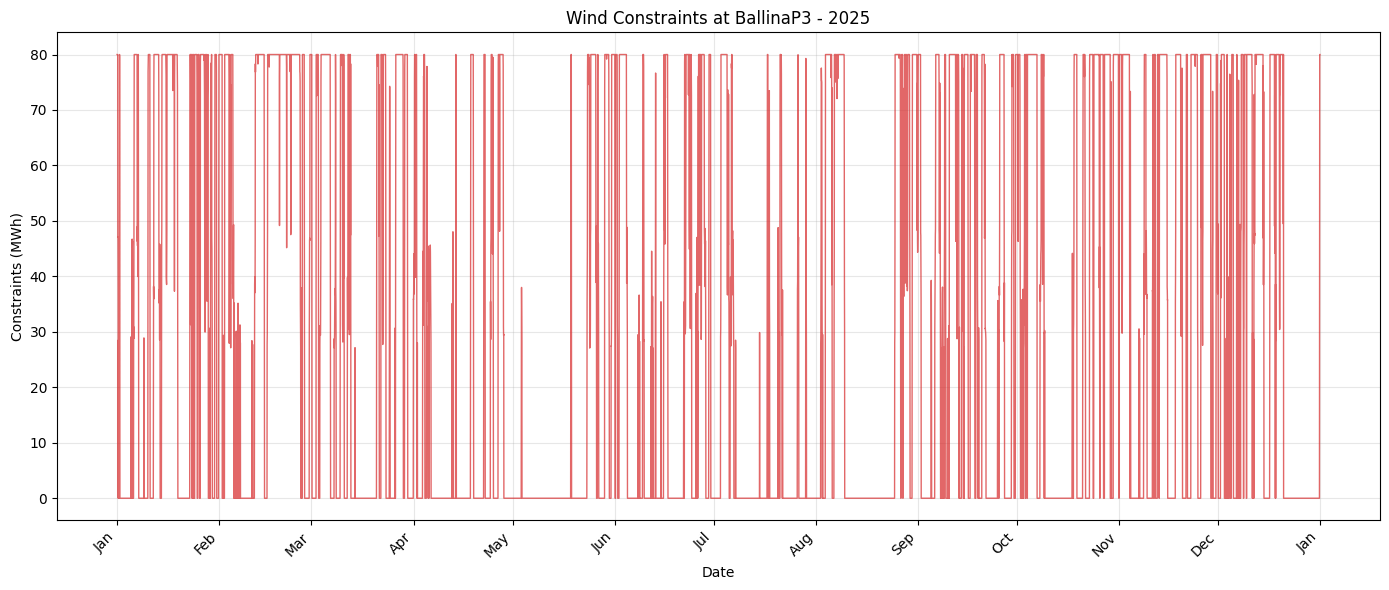


Constraint Statistics for BallinaP3 (2025):
  Total Constraints: 259505.13 MWh
  Mean Constraints: 29.6239 MWh
  Max Constraints: 80.00 MWh
  Min Constraints: 0.0000 MWh
  Percent of Available Capacity Constrained: 11.59%
RangeIndex(start=0, stop=5, step=1)
<class 'int'>


In [97]:
# plot the constraints over the year
c = constraints.copy().reset_index(drop=True)
c.index = pd.date_range(f"{year}-01-01", periods=len(c), freq="h")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(c.index, c["curtailment_hat_mwh"], lw=1, alpha=0.7, color="#d62728")
ax.set(title=f"Wind Constraints at {node_id} - {year}", xlabel="Date", ylabel="Constraints (MWh)")
ax.grid(True, alpha=0.3)

# show every month
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

fig.autofmt_xdate(rotation=45, ha="right")
plt.tight_layout(); plt.show()

# Calculate total constraints at the node
total_constraints = constraints['curtailment_hat_mwh'].sum()
mean_constraints = constraints['curtailment_hat_mwh'].mean()
max_constraints = constraints['curtailment_hat_mwh'].max()
min_constraints = constraints['curtailment_hat_mwh'].min()
percent_constrained = (total_constraints / availability['MWh Available'].sum()) * 100

print(f"\nConstraint Statistics for {node_id} ({year}):")
print(f"  Total Constraints: {total_constraints:.2f} MWh")
print(f"  Mean Constraints: {mean_constraints:.4f} MWh")
print(f"  Max Constraints: {max_constraints:.2f} MWh")
print(f"  Min Constraints: {min_constraints:.4f} MWh")
print(f"  Percent of Available Capacity Constrained: {percent_constrained:.2f}%")

# what was the original index type/values before pd.to_datetime?
print(constraints.index[:5])
print(type(constraints.index[0]))

In [98]:
Hourly_Profiles = availability.copy()
Hourly_Profiles = Hourly_Profiles.rename(columns={'MWh Available':'availability'}) 
Hourly_Profiles.head()


,availability
datetime,
2025-01-01 00:00:00+00:00,500.0
2025-01-01 01:00:00+00:00,500.0
2025-01-01 02:00:00+00:00,500.0
2025-01-01 03:00:00+00:00,500.0
2025-01-01 04:00:00+00:00,500.0


In [99]:
Hourly_Profiles['Constraints'] = constraints['curtailment_hat_mwh'].values

Hourly_Profiles.head()

,availability,Constraints
datetime,,
2025-01-01 00:00:00+00:00,500.0,80.0
2025-01-01 01:00:00+00:00,500.0,80.0
2025-01-01 02:00:00+00:00,500.0,80.0
2025-01-01 03:00:00+00:00,500.0,80.0
2025-01-01 04:00:00+00:00,500.0,80.0


In [100]:
# Load node hourly demand for the specified node
_nd = pd.read_csv("../../data/processed/demand/node_demand_hourly.csv")
_nd['DateTime'] = pd.to_datetime(_nd['DateTime'], utc=True).dt.tz_convert(None)
_nd = _nd.set_index('DateTime')
node_demand_arr = _nd[node_id].reindex(Hourly_Profiles.index.tz_convert(None)).fillna(0).values
print(f"Node demand for {node_id}: {len(node_demand_arr)} hours, mean {node_demand_arr.mean():.2f} MWh/h, max {node_demand_arr.max():.2f} MWh/h")
print(_nd.index[:3], Hourly_Profiles.index[:3])

Node demand for BallinaP3: 8760 hours, mean 505.29 MWh/h, max 764.84 MWh/h
DatetimeIndex(['2025-01-01 00:00:00', '2025-01-01 01:00:00',
               '2025-01-01 02:00:00'],
              dtype='datetime64[us]', name='DateTime', freq=None) DatetimeIndex(['2025-01-01 00:00:00+00:00', '2025-01-01 01:00:00+00:00',
               '2025-01-01 02:00:00+00:00'],
              dtype='datetime64[us, UTC]', name='datetime', freq='h')


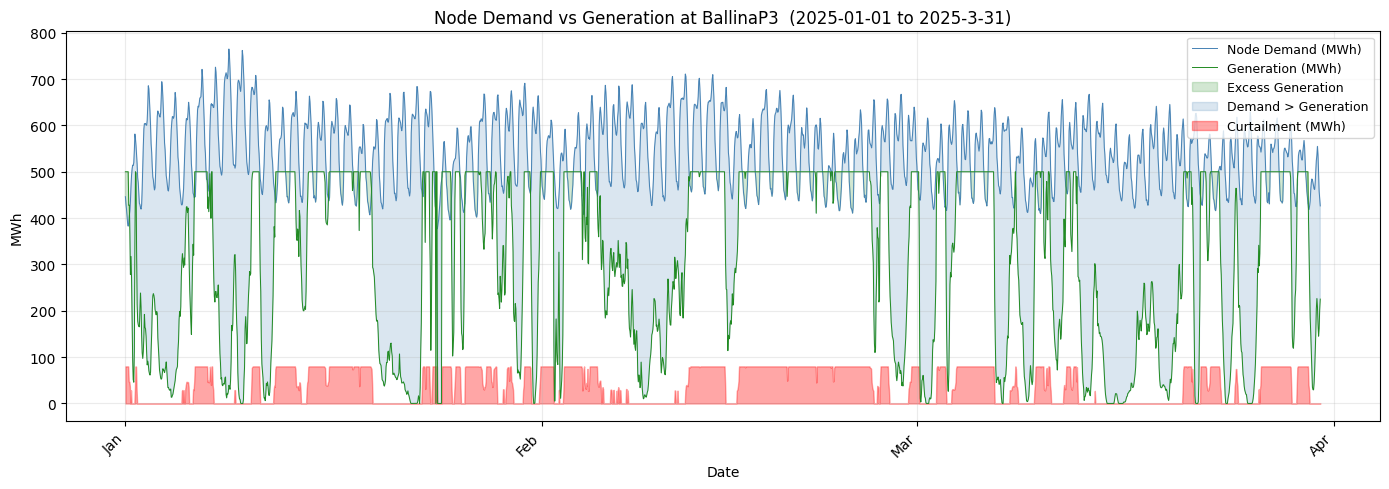

In [101]:
# === CHANGE THESE DATES TO ADJUST THE PLOT RANGE ===
plot_start = '2025-01-01'
plot_end   = '2025-3-31'
# ====================================================

mask      = (Hourly_Profiles.index >= plot_start) & (Hourly_Profiles.index <= plot_end)
plot_data = Hourly_Profiles.loc[mask]
nd_series = pd.Series(node_demand_arr, index=Hourly_Profiles.index).loc[mask]

gen_vals    = plot_data['availability'].values
demand_vals = nd_series.values
curt_vals   = plot_data['Constraints'].values

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(plot_data.index, demand_vals, lw=0.7, color='steelblue',   label='Node Demand (MWh)')
ax.plot(plot_data.index, gen_vals,   lw=0.7, color='forestgreen', label='Generation (MWh)')
ax.fill_between(plot_data.index, demand_vals, gen_vals,
                where=gen_vals > demand_vals, alpha=0.2, color='forestgreen',
                label='Excess Generation')
ax.fill_between(plot_data.index, demand_vals, gen_vals,
                where=gen_vals <= demand_vals, alpha=0.2, color='steelblue',
                label='Demand > Generation')
ax.fill_between(plot_data.index, 0, curt_vals, alpha=0.35, color='red',
                label='Curtailment (MWh)')

ax.set_title(f'Node Demand vs Generation at {node_id}  ({plot_start} to {plot_end})')
ax.set_xlabel('Date')
ax.set_ylabel('MWh')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.25)
fig.autofmt_xdate(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Wind Curtailment Data



# Manual Inputs

In [102]:
### Assumptions ###
# Elec price = €150/MWh (15c/kWh)
# Minimum battery charge 15%
# 90% RTE
# Battery power = 1/20 generator power, 4 hour capacity
# Capex €200k/MWh
# Opex 2% of capex

# Battery Characteristics

Batt_Size = 100   # Battery size in MW
Batt_Cap = 2        # Battery Capacity in hours
RTE = 0.90          # Round trip efficiency
init_charge = 0.7   # Initial battery charge


In [103]:
# Controls

min_charge = 0.15   # Minimum allowable battery charge

IncludeConstraints = True  # Include curtailment constraints (False to ignore)
IncludeArbitrage   = True  # Price-based arbitrage: cheap grid charging + peak selling

# Arbitrage parameters (only active when IncludeArbitrage = True)
ArbitrageChargeWindow    = [21, 17]  # Grid charge window: 21:00 prev day → 17:00 today
ArbitrageDischargeWindow = [17, 21]  # Sell window: 17:00–21:00
ArbitrageChargeDuration  = Batt_Cap  # Cheapest N hours to purchase within the charge window

In [125]:
# Financials

elec_price = 100          # €/MWh

grid_import_adder = 30    # €/MWh additional cost on grid imports (3c/kWh)

# DS3 Tariffs (post-Jan 2022 rates — 10% reduction from 2018 base rates, €/MWh contracted capacity)
DS3_TARIFFS = {
    "FFR":  1.94,   # Fast Frequency Response
    "POR":  2.92,   # Primary Operating Reserve
    "SOR":  1.76,   # Secondary Operating Reserve
    "TOR1": 1.40,   # Tertiary Operating Reserve 1
    "TOR2": 1.12,   # Tertiary Operating Reserve 2
}
DS3_FAS = 3.0    # Fast Acting Scalar  — applied to FFR for fast-responding technology (e.g. BESS)
DS3_CPS = 1.5    # Continuous Provision Scalar — applied to FFR when full stack (FFR+POR+SOR+TOR1) contracted simultaneously

# Temporal Scarcity Scalar thresholds (post-Oct 2024 rates)
# SNSP > 70%  →  TSS = 4.0
# SNSP 60–70% →  TSS = 2.25
# SNSP < 60%  →  TSS = 1.0  (no scalar)
DS3_TSS_BANDS = [(0.70, 4.0), (0.60, 2.25), (0.0, 1.0)]

# Set to True to remove the TSS entirely (all hours treated as TSS = 1.0).
DS3_TSS_REDUCED = True

# Fraction of theoretical DS3 headroom that translates to contracted, paid availability. 
# Accounts for SoC management, non-contracted hours, outages, and partial stack achievement.
# Predicted DS3 revenue by mid 2027
DS3_availability_factor = 0.2
_generators = pd.read_csv('../../data/raw/generators.csv')
DS3_MW_CAP = _generators[
    _generators['node_id'] == node_id
]['rated_MW'].sum()
print(f"Node connection capacity ({node_id}, all technologies): {DS3_MW_CAP:.1f} MW  → DS3_MW_CAP")

# === CRM (Capacity Remuneration Mechanism) ===
IncludeCRM         = True      # Set False to exclude CRM revenue entirely
crm_clearing_price = 149_960   # €/MW-derated/year — T-4 2028/29 clearing price (most recent T-4 new-build contract)
crm_contract_term  = 15        # Years of CRM revenue — matches the 15-year NPV term (asset re-contracts over its life)
crm_loss_factor    = 0.15      # 15% reduction to account for Difference Charge & performance penalties

capex = 200000            # CapEx in €/MWh
opex  = capex * 0.02      # OpEx in €/MWh/year (2% of capex)

Node connection capacity (BallinaP3, all technologies): 500.0 MW  → DS3_MW_CAP


In [105]:
# === CRM Derating Factor (DRF) lookup table ===
# Source: IAIP DRF table (IC MW band × Hours of Storage)
# Rows = IC upper bounds (MW); Columns = hours of storage

_DRF_IC_BOUNDS = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160]
_DRF_HOURS     = [0.5,   1,   1.5,   2,     3,     4  ]
_DRF_TABLE     = [
    #  0.5    1      1.5    2      3      4        IC band
    [0.042, 0.072, 0.111, 0.146, 0.214, 0.278],  # 0   < IC ≤  10
    [0.040, 0.072, 0.110, 0.145, 0.214, 0.278],  # 10  < IC ≤  20
    [0.039, 0.072, 0.109, 0.144, 0.213, 0.278],  # 20  < IC ≤  30
    [0.038, 0.072, 0.108, 0.144, 0.212, 0.277],  # 30  < IC ≤  40
    [0.036, 0.072, 0.108, 0.143, 0.212, 0.277],  # 40  < IC ≤  50
    [0.036, 0.072, 0.107, 0.143, 0.211, 0.277],  # 50  < IC ≤  60
    [0.036, 0.072, 0.107, 0.143, 0.211, 0.277],  # 60  < IC ≤  70
    [0.036, 0.072, 0.107, 0.142, 0.211, 0.276],  # 70  < IC ≤  80
    [0.036, 0.072, 0.107, 0.142, 0.210, 0.276],  # 80  < IC ≤  90
    [0.036, 0.072, 0.107, 0.142, 0.210, 0.275],  # 90  < IC ≤ 100
    [0.035, 0.072, 0.107, 0.142, 0.209, 0.275],  # 100 < IC ≤ 110
    [0.035, 0.071, 0.107, 0.141, 0.209, 0.274],  # 110 < IC ≤ 120
    [0.035, 0.071, 0.106, 0.141, 0.209, 0.274],  # 120 < IC ≤ 130
    [0.035, 0.071, 0.106, 0.141, 0.208, 0.273],  # 130 < IC ≤ 140
    [0.035, 0.071, 0.106, 0.141, 0.208, 0.273],  # 140 < IC ≤ 150
    [0.035, 0.071, 0.106, 0.141, 0.208, 0.272],  # 150 < IC ≤ 160
]

def get_drf(ic_mw, hours):
    """Return the IAIP Derating Factor for a BESS with given IC (MW) and storage duration (hours).
    Interpolates linearly over duration; clamps both IC and duration to table bounds."""
    band_idx = next((i for i, b in enumerate(_DRF_IC_BOUNDS) if ic_mw <= b), len(_DRF_IC_BOUNDS) - 1)
    drf_row  = _DRF_TABLE[band_idx]
    return float(np.interp(np.clip(hours, _DRF_HOURS[0], _DRF_HOURS[-1]), _DRF_HOURS, drf_row))

# Quick sanity check for current battery settings
print(f"DRF for {Batt_Size} MW / {Batt_Cap} hr: {get_drf(Batt_Size, Batt_Cap):.4f}")
print(f"De-rated capacity: {Batt_Size * get_drf(Batt_Size, Batt_Cap):.3f} MW")

DRF for 100 MW / 2 hr: 0.1420
De-rated capacity: 14.200 MW


# Create Inputs Dataframe

In [106]:
df = pd.DataFrame({
    'Time Stamp': Hourly_Profiles.index,
    'Node Demand (MWh)': node_demand_arr,
    'Generation (MWh)': Hourly_Profiles['availability'],
    'Constraints': Hourly_Profiles['Constraints']
})

df

,Time Stamp,Node Demand (MWh),Generation (MWh),Constraints
datetime,,,,
2025-01-01 00:00:00+00:00,2025-01-01 00:00:00+00:00,446.318179,500.000000,80.000000
2025-01-01 01:00:00+00:00,2025-01-01 01:00:00+00:00,429.998320,500.000000,80.000000
2025-01-01 02:00:00+00:00,2025-01-01 02:00:00+00:00,418.679100,500.000000,80.000000
2025-01-01 03:00:00+00:00,2025-01-01 03:00:00+00:00,403.935209,500.000000,80.000000
2025-01-01 04:00:00+00:00,2025-01-01 04:00:00+00:00,388.189593,500.000000,80.000000
...,...,...,...,...
2025-12-31 19:00:00+00:00,2025-12-31 19:00:00+00:00,604.998607,208.438158,0.000000
2025-12-31 20:00:00+00:00,2025-12-31 20:00:00+00:00,568.445346,291.888982,0.000000
2025-12-31 21:00:00+00:00,2025-12-31 21:00:00+00:00,539.944584,433.723569,47.709593


In [107]:
# Node demand is already loaded as node_demand_arr and stored in df['Node Demand (MWh)']
# Discharge is capped directly by node demand — no remaining-load calculation needed
print(f"Node demand summary: mean {df['Node Demand (MWh)'].mean():.2f}, max {df['Node Demand (MWh)'].max():.2f} MWh/h")

Node demand summary: mean 505.29, max 764.84 MWh/h


In [108]:
print(f"{df['Generation (MWh)'].sum():,}")

2,239,291.443899608


In [109]:
df['Node Demand (MWh)'] = df['Node Demand (MWh)'].fillna(0)

In [110]:
# Initial Battery Charge

init_charge_MWh = init_charge*Batt_Cap*Batt_Size
init_charge_MWh

140.0

In [111]:
# Derived Battery Constants

Batt_Loss = (1 - RTE) / 2                     # Battery Loss per charge/discharge
Max_Charge = Batt_Size * Batt_Cap             # max battery energy (MWh)
Min_Charge_MWh = Max_Charge * min_charge      # min battery energy (MWh)
Batt_Pow = Batt_Size                 

# Time Series Calculations

In [112]:
# ============================================================
# Build price_arr: hourly prices aligned to simulation year
# Prices matched by month + day-of-month + hour so that, e.g.,
# the simulation hour 2025-02-02 01:00 uses the price for 02-02 01:00
# from the price data (regardless of which year it comes from).
# The most recent year's price is used for each month/day/hour.
# ============================================================

price_data['_month'] = price_data['Timestamp_UTC'].dt.month
price_data['_day']   = price_data['Timestamp_UTC'].dt.day
price_data['_hour']  = price_data['Timestamp_UTC'].dt.hour

price_lookup = (
    price_data
    .sort_values('Timestamp_UTC')
    .drop_duplicates(subset=['_month', '_day', '_hour'], keep='last')
    .set_index(['_month', '_day', '_hour'])['Price']
)

price_arr = np.array([
    price_lookup.get((ts.month, ts.day, ts.hour), elec_price)
    for ts in df.index
])

if not IncludeConstraints:
    df['Constraints'] = np.zeros(len(df))

# Wind flowing to grid = unconstrained generation (no local load comparison needed)
# Curtailment absorbed by the battery is excluded from wind grid output
wind_consumed_arr   = np.maximum(0, df['Generation (MWh)'].values - df['Constraints'].values)
wind_revenue_arr    = wind_consumed_arr * price_arr
total_wind_consumed = wind_consumed_arr.sum()
total_wind_revenue  = wind_revenue_arr.sum()

print(f"Price array: {len(price_arr)} hours, "
      f"mean €{price_arr.mean():.2f}/MWh, "
      f"min €{price_arr.min():.2f}/MWh, "
      f"max €{price_arr.max():.2f}/MWh")
print(f"Total unconstrained wind output: {total_wind_consumed:,.0f} MWh")
print(f"Total wind revenue (at spot price): €{total_wind_revenue:,.0f}")

Price array: 8760 hours, mean €107.07/MWh, min €-23.50/MWh, max €465.77/MWh
Total unconstrained wind output: 1,979,786 MWh
Total wind revenue (at spot price): €186,669,932


In [113]:
# ============================================================
# Load hourly SNSP and compute per-hour TSS array
# TSS (Temporal Scarcity Scalar) multiplies all DS3 payments
# based on the mean SNSP in each hour.
# Post-Oct 2024: SNSP >70% → 4.0 | 60–70% → 2.25 | <60% → 1.0
# DS3_TSS_REDUCED = True overrides all hours to TSS = 1.0
# ============================================================

_snsp_raw = pd.read_csv(
    "../../data/processed/snsp/snsp_hourly_2025.csv",
    parse_dates=["DateTime"]
).set_index("DateTime")["SNSP"]

# SNSP timestamps are Irish local time (tz-naive); df.index is UTC-aware.
# Localize to Europe/Dublin then convert to UTC so reindex matches correctly.
# nonexistent='NaT' handles the spring-forward DST gap (30 Mar 01:00 local).
_snsp_raw.index = (
    _snsp_raw.index
    .tz_localize("Europe/Dublin", nonexistent="NaT", ambiguous="NaT")
    .tz_convert("UTC")
)
_snsp_utc = _snsp_raw[_snsp_raw.index.notna()]  # drop any NaT from DST boundaries

snsp_arr = _snsp_utc.reindex(df.index, fill_value=_snsp_utc.mean()).values

def _tss(snsp):
    for threshold, scalar in DS3_TSS_BANDS:
        if snsp > threshold:
            return scalar
    return 1.0

if DS3_TSS_REDUCED:
    tss_arr = np.ones(len(snsp_arr))
    tss_label = "REDUCED (all hours TSS = 1.0)"
else:
    tss_arr = np.vectorize(_tss)(snsp_arr)
    tss_label = "live SNSP bands"

print(f"SNSP loaded: {len(snsp_arr)} hours  |  mean SNSP = {snsp_arr.mean():.3f}  |  TSS mode: {tss_label}")
print(f"TSS distribution:  1.0 (SNSP <60%)  → {(tss_arr == 1.0).mean():.1%}  |  "
      f"2.25 (60–70%) → {(tss_arr == 2.25).mean():.1%}  |  "
      f"4.0  (>70%)   → {(tss_arr == 4.0).mean():.1%}")

SNSP loaded: 8760 hours  |  mean SNSP = 0.506  |  TSS mode: REDUCED (all hours TSS = 1.0)
TSS distribution:  1.0 (SNSP <60%)  → 100.0%  |  2.25 (60–70%) → 0.0%  |  4.0  (>70%)   → 0.0%


In [114]:
# ============================================================
# Day-ahead grid charging schedule pre-computation
# ============================================================

def compute_grid_charge_schedule(Max_Charge_v, Min_Charge_MWh_v, Batt_Pow_v,
                                  one_minus_loss_v, con_arr, h_arr, p_arr):
    """
    Pre-compute day-ahead grid charging schedule for price arbitrage.
    Returns float array (8760,) with MWh of scheduled grid charging per hour.
    Only charges the battery from the grid when curtailment alone can't fill it,
    using the cheapest ArbitrageChargeDuration-hour window
    between 21:00 the previous day and 17:00 the current day.
    """
    n_v      = len(con_arr)
    n_slots  = ArbitrageChargeDuration
    d_s, d_e = ArbitrageDischargeWindow   # e.g. 17, 21

    # --- Pass 1: forward-predict SOC without grid charging ---
    pred_soc = np.empty(n_v + 1)
    pred_soc[0] = init_charge * Max_Charge_v

    for i in range(n_v):
        soc = pred_soc[i]
        con = con_arr[i]
        h   = h_arr[i]

        # Natural charging: curtailment-based only
        charge = 0.0
        if con > 0 and soc < Max_Charge_v:
            charge = min(Batt_Pow_v, (Max_Charge_v - soc) / one_minus_loss_v)

        # Predicted discharge: only in arbitrage sell window
        discharge = 0.0
        if d_s <= h < d_e and soc > Min_Charge_MWh_v and con == 0:
            discharge = min(soc - Min_Charge_MWh_v, Batt_Pow_v)

        pred_soc[i + 1] = soc + charge * one_minus_loss_v - discharge

    # --- Pass 2: for each day find cheapest grid-charge window ---
    schedule = np.zeros(n_v)

    for d in range(365):
        # Natural fill window: 21:00 day d-1 → 17:00 day d
        # Grid charge window: same range (buy cheapest power between discharge cycles)
        d_s_hour, d_e_hour = ArbitrageDischargeWindow  # 17, 21

        if d == 0:
            fill_start = 0
            w_start    = 0
        else:
            fill_start = (d - 1) * 24 + d_e_hour      # 21:00 prev day
            w_start    = fill_start

        fill_end = min(d * 24 + d_s_hour, n_v)         # 17:00 today
        w_end    = fill_end

        if w_end - w_start < n_slots:
            continue

        # SOC at start of window (post-discharge)
        soc_at_start = pred_soc[fill_start]

        # Natural fill: curtailment charging between 21:00(d-1) and 17:00(d)
        natural_fill = 0.0
        for i in range(fill_start, fill_end):
            con = con_arr[i]
            if con > 0:
                natural_fill += min(con, Batt_Pow_v)

        soc_after_natural = min(soc_at_start + natural_fill * one_minus_loss_v, Max_Charge_v)
        remaining         = Max_Charge_v - soc_after_natural

        if remaining <= 0:
            continue

        # Get prices for the window
        wp = p_arr[w_start:w_end]
        
        # 1. Find the indices of the N cheapest hours (not necessarily contiguous)
        # np.argsort returns indices that would sort the array
        cheapest_indices = np.argsort(wp)[:n_slots]

        grid_needed    = remaining / one_minus_loss_v
        power_per_hour = min(grid_needed / n_slots, Batt_Pow_v)

        # 2. Schedule charging only during those specific best hours
        for k in cheapest_indices:
            idx = w_start + k
            if idx < n_v:
                schedule[idx] += power_per_hour

    return schedule


# Compute schedule (or zeros if arbitrage disabled)
if IncludeArbitrage:
    _con_sched = df['Constraints'].values.copy()
    if not IncludeConstraints:
        _con_sched[:] = 0.0
    _h_sched = df.index.hour.values

    grid_charge_schedule_arr = compute_grid_charge_schedule(
        Max_Charge, Min_Charge_MWh, Batt_Pow, 1 - Batt_Loss,
        _con_sched, _h_sched, price_arr
    )
    print(f"Grid charge schedule: {(grid_charge_schedule_arr > 0).sum()} hours, "
          f"{grid_charge_schedule_arr.sum():.1f} MWh planned grid charge")
else:
    grid_charge_schedule_arr = np.zeros(len(df))
    print("Arbitrage disabled — grid charge schedule set to zero")

Grid charge schedule: 286 hours, 24105.2 MWh planned grid charge


In [115]:
import time
start_time = time.time()

# Extract hour and month directly from DatetimeIndex
hours     = df.index.hour.values
month_arr = df.index.month.values

# Discharging timing: restrict to peak sell window when arbitrage enabled
if IncludeArbitrage:
    d_start, d_end  = ArbitrageDischargeWindow
    discharging_arr = ((hours >= d_start) & (hours < d_end)).astype(int)
else:
    discharging_arr = np.ones(len(df), dtype=int)

# Node demand and constraints as numpy arrays
node_demand_arr = df['Node Demand (MWh)'].values   # caps discharge each hour
constraints_arr = df['Constraints'].values

# Zero out constraints if disabled
if not IncludeConstraints:
    constraints_arr = np.zeros_like(constraints_arr)
    df['Constraints'] = constraints_arr

# Pre-compute loop constants
one_minus_loss = 1 - Batt_Loss

# === Sequential simulation ===
n = len(df)
charge_status       = np.zeros(n)
max_charge_amt      = np.zeros(n)
max_discharge_amt   = np.zeros(n)
max_grid_charge_amt = np.zeros(n)   # Grid electricity drawn for arbitrage charging

prev_charge = init_charge_MWh

for i in range(n):
    node_demand = node_demand_arr[i]
    discharging = discharging_arr[i]
    constraint  = constraints_arr[i]

    has_constraint = constraint > 0

    # Max allowable discharge — blocked when constraints are active
    # Discharge is capped by node demand at this node
    Max_dis = 0
    if not has_constraint:
        DC_Cap = prev_charge > Min_Charge_MWh
        if discharging and DC_Cap:
            spare_dis = prev_charge - Min_Charge_MWh
            Max_dis = min(spare_dis, Batt_Pow, node_demand / one_minus_loss)
            if Max_dis < 0:
                Max_dis = 0
    max_discharge_amt[i] = Max_dis

    # Max allowable charge: constraint-based (curtailed wind)
    Max_C = 0
    if has_constraint and prev_charge < Max_Charge:
        available_space = (Max_Charge - prev_charge) / one_minus_loss
        Max_C = min(constraint, Batt_Pow, available_space)
        if Max_C < 0:
            Max_C = 0

    # Additive grid charging from pre-computed arbitrage schedule
    # (Does not fire during constrained hours)
    grid_c = grid_charge_schedule_arr[i]
    if grid_c > 0 and not has_constraint and prev_charge < Max_Charge:
        available_space = (Max_Charge - prev_charge) / one_minus_loss
        extra = max(min(grid_c, available_space - Max_C), 0.0)
        Max_C += extra
        max_grid_charge_amt[i] = extra

    max_charge_amt[i] = Max_C

    # Updated battery SOC
    prev_charge = prev_charge + Max_C * one_minus_loss - Max_dis
    charge_status[i] = prev_charge

# Post-loop vectorised calculations
net_charge = max_charge_amt * one_minus_loss - max_discharge_amt
energy_io  = max_charge_amt - max_discharge_amt * one_minus_loss

# Wind charge (constraint-based) vs grid charge (arbitrage)
wind_charge_arr = max_charge_amt - max_grid_charge_amt
grid_import     = max_grid_charge_amt
grid_export     = np.zeros(n)

battery_action = np.where(
    net_charge > 0, 'CHARGING',
    np.where(net_charge < 0, 'DISCHARGING', 'NO ACTIVITY')
)

# === DS3 FFR Upward Availability ===
ds3_discharge_headroom = np.maximum(0, charge_status - Min_Charge_MWh)
ds3_available_mw       = np.minimum(Batt_Pow, ds3_discharge_headroom / Batt_Cap) - max_discharge_amt
ds3_available_mw       = np.maximum(0, ds3_available_mw)
ds3_available_mw       = np.minimum(ds3_available_mw, DS3_MW_CAP)
ds3_available_mw       = ds3_available_mw * DS3_availability_factor

# Assign results to dataframe
df['Net Charge']         = net_charge
df['Charge Status']      = charge_status
df['Battery Action']     = battery_action
df['Energy Flow']        = energy_io
df['Grid Import']        = grid_import
df['Grid Export']        = grid_export
df['Grid Charge (MWh)']  = max_grid_charge_amt
df['DS3 Available (MW)'] = ds3_available_mw

elapsed = time.time() - start_time
print(f"Time series calculation completed in {elapsed:.3f} seconds")
print(f"DS3 FFR availability: {(ds3_available_mw > 0).sum()} hours, "
      f"avg {ds3_available_mw[ds3_available_mw > 0].mean():.1f} MW when available")


Time series calculation completed in 0.243 seconds
DS3 FFR availability: 6391 hours, avg 16.0 MW when available


# Table

In [116]:
pd.set_option('display.max_rows',100)
display(df[0:5])

,Time Stamp,Node Demand (MWh),Generation (MWh),Constraints,Net Charge,Charge Status,Battery Action,Energy Flow,Grid Import,Grid Export,Grid Charge (MWh),DS3 Available (MW)
datetime,,,,,,,,,,,,
2025-01-01 00:00:00+00:00,2025-01-01 00:00:00+00:00,446.318179,500.0,80.0,60.0,200.0,CHARGING,63.157895,0.0,0.0,0.0,17.0
2025-01-01 01:00:00+00:00,2025-01-01 01:00:00+00:00,429.998320,500.0,80.0,0.0,200.0,NO ACTIVITY,0.000000,0.0,0.0,0.0,17.0
2025-01-01 02:00:00+00:00,2025-01-01 02:00:00+00:00,418.679100,500.0,80.0,0.0,200.0,NO ACTIVITY,0.000000,0.0,0.0,0.0,17.0
2025-01-01 03:00:00+00:00,2025-01-01 03:00:00+00:00,403.935209,500.0,80.0,0.0,200.0,NO ACTIVITY,0.000000,0.0,0.0,0.0,17.0
2025-01-01 04:00:00+00:00,2025-01-01 04:00:00+00:00,388.189593,500.0,80.0,0.0,200.0,NO ACTIVITY,0.000000,0.0,0.0,0.0,17.0


# Load Profile Summary

In [117]:
# Load Profile Summary Table

max_node_demand_MWh    = df['Node Demand (MWh)'].max()
avg_node_demand_MWh    = df['Node Demand (MWh)'].mean()
total_generation_MWh   = df['Generation (MWh)'].sum()
total_constraints_MWh  = df['Constraints'].sum()
unconstrained_gen_MWh  = total_generation_MWh - total_constraints_MWh

summary = pd.DataFrame({
    'Metric': [
        'Max Node Demand',
        'Average Node Demand',
        'Total Generation (Annual)',
        'Total Curtailment (Annual)',
        'Unconstrained Generation (Annual)',
    ],
    'Value': [
        f"{max_node_demand_MWh:,.2f} MWh/h",
        f"{avg_node_demand_MWh:,.2f} MWh/h",
        f"{total_generation_MWh:,.0f} MWh",
        f"{total_constraints_MWh:,.0f} MWh",
        f"{unconstrained_gen_MWh:,.0f} MWh",
    ]
})

summary.style.hide(axis='index')

Metric,Value
Max Node Demand,764.84 MWh/h
Average Node Demand,505.29 MWh/h
Total Generation (Annual),"2,239,291 MWh"
Total Curtailment (Annual),"259,505 MWh"
Unconstrained Generation (Annual),"1,979,786 MWh"


# Battery Operation Summary

In [118]:
# Battery Operation Summary Table

# Charge into battery (before RTE losses)
total_charge_in = df.loc[df['Energy Flow'] > 0, 'Energy Flow'].sum()

# Discharge out of battery (after RTE losses)
total_discharge_out = df.loc[df['Energy Flow'] < 0, 'Energy Flow'].sum()

# Percentage of curtailment captured by the battery
curtailment_captured = np.minimum(df['Constraints'].values, np.maximum(df['Energy Flow'].values, 0)).sum()
total_constraints_val = df['Constraints'].sum()
pct_curtailment_captured = (curtailment_captured / total_constraints_val * 100) if total_constraints_val > 0 else 0

# Hours in each state
hours_charging    = (df['Battery Action'] == 'CHARGING').sum()
hours_discharging = (df['Battery Action'] == 'DISCHARGING').sum()
hours_static      = (df['Battery Action'] == 'NO ACTIVITY').sum()

# Hours fully charged / fully discharged
hours_fully_charged    = (df['Charge Status'] >= Max_Charge).sum()
hours_fully_discharged = (df['Charge Status'] <= Min_Charge_MWh).sum()

# Cycles per year
cycles_per_year = total_charge_in / Max_Charge

batt_summary = pd.DataFrame({
    'Metric': [
        'Total Charge into Battery (before RTE losses)',
        'Total Discharge from Battery (after RTE losses)',
        'Curtailment Captured',
        'Cycles per Year',
        'Hours Charging',
        'Hours Discharging',
        'Hours Static',
        'Hours Fully Charged',
        'Hours Fully Discharged'
    ],
    'Value': [
        f"{total_charge_in:,.0f} MWh",
        f"{total_discharge_out:,.0f} MWh",
        f"{pct_curtailment_captured:,.1f}%",
        f"{cycles_per_year:,.1f}",
        f"{hours_charging:,.1f} hrs",
        f"{hours_discharging:,.1f} hrs",
        f"{hours_static:,.1f} hrs",
        f"{hours_fully_charged:,.1f} hrs",
        f"{hours_fully_discharged:,.1f} hrs"
    ]
})

batt_summary.style.hide(axis='index')

Metric,Value
Total Charge into Battery (before RTE losses),"38,666 MWh"
Total Discharge from Battery (after RTE losses),"-34,839 MWh"
Curtailment Captured,5.7%
Cycles per Year,193.3
Hours Charging,637.0 hrs
Hours Discharging,432.0 hrs
Hours Static,"7,691.0 hrs"
Hours Fully Charged,"5,627.0 hrs"
Hours Fully Discharged,"2,149.0 hrs"


In [119]:
# Average Charge and Discharge Powers

charging_mask = df['Battery Action'] == "CHARGING"
discharging_mask = df['Battery Action']  == 'DISCHARGING'

avg_charge_power = df.loc[charging_mask, 'Energy Flow'].mean()
avg_discharge_power = -df.loc[discharging_mask, 'Energy Flow'].mean()

print(f"Average Charge Power:    {avg_charge_power:,.2f} MW  ")
print(f"Average Discharge Power: {avg_discharge_power:,.2f} MW  ")

Average Charge Power:    60.70 MW  
Average Discharge Power: 80.64 MW  


In [120]:
hours_constrained   = (df['Constraints'] > 0).sum()
hours_unconstrained = (df['Constraints'] == 0).sum()
hours_with_demand   = (df['Node Demand (MWh)'] > 0).sum()

print(f"Hours where the system is constrained:   {hours_constrained}")
print(f"Hours where the system is unconstrained: {hours_unconstrained}")
print(f"Hours with node demand > 0:              {hours_with_demand}")

Hours where the system is constrained:   3720
Hours where the system is unconstrained: 5040
Hours with node demand > 0:              8760


# Revenue and NPV Calculations


In [121]:
# === Revenue Calculations ===

# Battery discharge revenue: actual MWh delivered = discharge × (1 - loss), at spot price
discharge_revenue_arr   = max_discharge_amt * one_minus_loss * price_arr
total_discharge_revenue = discharge_revenue_arr.sum()

# Grid charging cost: MWh drawn from grid for arbitrage, at spot price + import adder
grid_charge_cost_arr   = max_grid_charge_amt * (price_arr + grid_import_adder)
total_grid_charge_cost = grid_charge_cost_arr.sum()

# DS3 multi-service revenue — full "Fast Five" stack: FFR + POR + SOR + TOR1 + TOR2
# FFR payment: base rate × FAS (3×) × CPS (1.5×) = 4.5× base, then × TSS
# Other services: base rate × TSS only
# Duration = 1.0 hr (hourly model); payment formula = contracted_MW × tariff × duration × scalars
DURATION   = 1.0   # hours per period
ffr_rate   = DS3_TARIFFS["FFR"] * DS3_FAS * DS3_CPS        # €9.27/MWh at base TSS
other_rate = sum(DS3_TARIFFS[s] for s in ("POR", "SOR", "TOR1", "TOR2"))  # €7.24/MWh

# Per-hour effective rate (MW × this → €)
ds3_rate_arr    = (ffr_rate + other_rate) * tss_arr * DURATION
ds3_revenue_arr = ds3_available_mw * ds3_rate_arr
total_ds3_revenue = ds3_revenue_arr.sum()

# === CRM Revenue ===
# De-rated capacity based on IAIP DRF table (size + duration)
crm_drf       = get_drf(Batt_Size, Batt_Cap)
crm_c_derated = Batt_Size * crm_drf                                      # MW-derated
crm_annual_gross = crm_c_derated * crm_clearing_price                    # € gross
crm_annual_net   = crm_annual_gross * (1 - crm_loss_factor) if IncludeCRM else 0.0  # after 15% loss

# Add revenue/cost columns to dataframe
df['Wind Revenue (€)']      = wind_revenue_arr
df['Discharge Revenue (€)'] = discharge_revenue_arr
df['Grid Charge Cost (€)']  = grid_charge_cost_arr
df['DS3 Revenue (€)']       = ds3_revenue_arr

# Annual opex and capex
annual_opex = Batt_Cap * Batt_Size * opex
batt_cost   = Batt_Cap * Batt_Size * capex

# Net annual battery revenue (excludes wind revenue — only arbitrage margin + DS3)
net_annual_revenue = (total_discharge_revenue
                      - total_grid_charge_cost
                      + total_ds3_revenue
                      - annual_opex)

# Payback
simple_payback = batt_cost / (net_annual_revenue + crm_annual_net) if (net_annual_revenue + crm_annual_net) > 0 else float('inf')

# NPV parameters
inflation_rate   = 0.02
discount_rate    = 0.04
degradation_rate = 0.02   # 2% capacity degradation per year
term             = 15

# CRM NPV: payments indexed to inflation over contract term (no degradation applied to capacity contract)
crm_npv = sum(
    crm_annual_net * (1 + inflation_rate)**yr / (1 + discount_rate)**yr
    for yr in range(1, crm_contract_term + 1)
) if IncludeCRM else 0.0

# Operating revenue NPV: arbitrage + DS3, degrading over time
ops_npv = sum(
    net_annual_revenue * (1 - degradation_rate)**yr * (1 + inflation_rate)**yr / (1 + discount_rate)**yr
    for yr in range(1, term + 1)
)

npv = -batt_cost + crm_npv + ops_npv

# IRR: find discount rate r that makes NPV = 0
from scipy.optimize import brentq as _brentq
def _irr(cashflows):
    """Return IRR for a cashflow list where cf[0] is the year-0 outflow."""
    def _npv_r(r):
        return sum(cf / (1 + r) ** t for t, cf in enumerate(cashflows))
    if _npv_r(0) <= 0:          # loss-making at r=0 → no positive IRR
        return float('nan')
    try:
        return _brentq(_npv_r, -0.5, 10.0)
    except ValueError:
        return float('nan')

_irr_cf = [-batt_cost]
for _yr in range(1, term + 1):
    _annual = net_annual_revenue * (1 - degradation_rate) ** _yr * (1 + inflation_rate) ** _yr
    if IncludeCRM and _yr <= crm_contract_term:
        _annual += crm_annual_net * (1 + inflation_rate) ** _yr
    _irr_cf.append(_annual)
irr = _irr(_irr_cf)

# DS3 per-service breakdown for diagnostics
ds3_ffr_total   = (ds3_available_mw * DS3_TARIFFS["FFR"] * DS3_FAS * DS3_CPS * tss_arr * DURATION).sum()
ds3_other_total = total_ds3_revenue - ds3_ffr_total
print(f"Battery Size: {Batt_Cap*Batt_Pow} MWh  |  Power: {Batt_Pow} MW ")
print(f"Wind Revenue (at spot price):    €{total_wind_revenue:>12,.0f}")
print(f"Battery Discharge Revenue:       €{total_discharge_revenue:>12,.0f}")
print(f"Grid Charging Cost (arbitrage): -€{total_grid_charge_cost:>12,.0f}")
print(f"Arbitrage Net Margin:            €{total_discharge_revenue - total_grid_charge_cost:>12,.0f}")
print()
print(f"DS3 Revenue (total):             €{total_ds3_revenue:>12,.0f}")
print(f"  of which FFR (×FAS×CPS×TSS):  €{ds3_ffr_total:>12,.0f}")
print(f"  of which POR+SOR+TOR1+TOR2:   €{ds3_other_total:>12,.0f}")
print(f"  mean effective DS3 rate:       €{ds3_rate_arr[ds3_available_mw > 0].mean():.2f}/MW/hr"
      f"  (TSS-weighted)")
print()
if IncludeCRM:
    print(f"CRM Revenue:")
    print(f"  DRF ({Batt_Size} MW / {Batt_Cap} hr):          {crm_drf:.4f}")
    print(f"  De-rated capacity:               {crm_c_derated:>8.3f} MW")
    print(f"  Gross annual CRM:                €{crm_annual_gross:>12,.0f}")
    print(f"  Net annual CRM (after {crm_loss_factor*100:.0f}% loss): €{crm_annual_net:>12,.0f}")
    print(f"  CRM NPV ({crm_contract_term}-yr, {inflation_rate*100:.1f}% inflation): €{crm_npv:>12,.0f}")
    print()
print(f"Annual OpEx:                    -€{annual_opex:>12,.0f}")
print(f"Net Annual Battery Revenue:      €{net_annual_revenue:>12,.0f}")
print()
print(f"Initial cost of battery:         €{batt_cost:>12,.0f}")
print(f"Simple Payback:                  {simple_payback:>11.2f} years")
print(f"15-year NPV ({inflation_rate*100:.1f}% inflation, {discount_rate*100:.1f}% discount, "
      f"{degradation_rate*100:.1f}% degradation): €{npv:,.0f}")
print(f"IRR ({term}-year):                       "
      f"{irr*100:.2f}%" if not np.isnan(irr) else "IRR ({term}-year):                       N/A")
print()
print(f"Revenue per MW")
print(f"Arbitrage Net Margin:            €{(total_discharge_revenue - total_grid_charge_cost)/Batt_Pow:>12,.0f}")
print(f"Crm Revenue:                       €{crm_annual_net/Batt_Pow:>12,.0f}")
print(f"DS3 Revenue (total):             €{total_ds3_revenue/Batt_Pow:>12,.0f}")
print(f"  of which FFR (×FAS×CPS×TSS):  €{ds3_ffr_total/Batt_Pow:>12,.0f}")
print(f"  of which POR+SOR+TOR1+TOR2:   €{ds3_other_total/Batt_Pow:>12,.0f}")

Battery Size: 200 MWh  |  Power: 100 MW 
Wind Revenue (at spot price):    € 186,669,932
Battery Discharge Revenue:       €   5,475,376
Grid Charging Cost (arbitrage): -€   2,830,455
Arbitrage Net Margin:            €   2,644,921

DS3 Revenue (total):             €   1,629,218
  of which FFR (×FAS×CPS×TSS):  €     892,848
  of which POR+SOR+TOR1+TOR2:   €     736,370
  mean effective DS3 rate:       €15.93/MW/hr  (TSS-weighted)

CRM Revenue:
  DRF (100 MW / 2 hr):          0.1420
  De-rated capacity:                 14.200 MW
  Gross annual CRM:                €   2,129,432
  Net annual CRM (after 15% loss): €   1,810,017
  CRM NPV (15-yr, 2.0% inflation): €  23,325,767

Annual OpEx:                    -€     800,000
Net Annual Battery Revenue:      €   3,474,139

Initial cost of battery:         €  40,000,000
Simple Payback:                         7.57 years
15-year NPV (2.0% inflation, 4.0% discount, 2.0% degradation): €21,840,428
IRR (15-year):                       10.85%

Revenue 

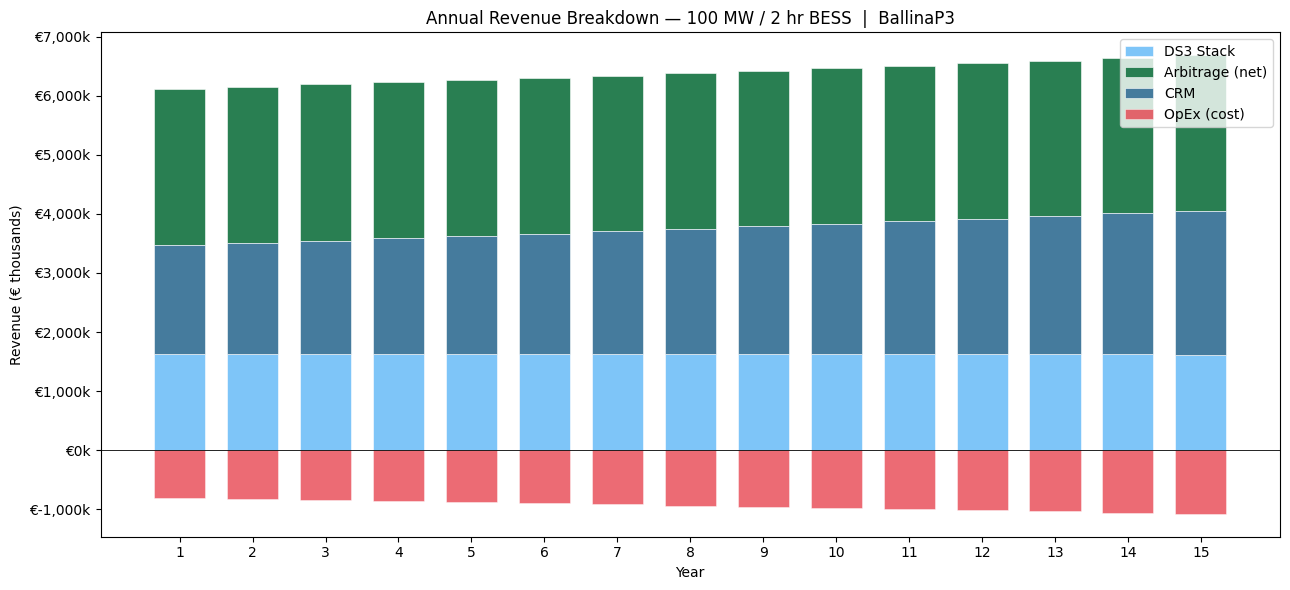

Year     Arbitrage           DS3           CRM          OpEx           Net
----------------------------------------------------------------------
   1  €   2,643.9k  €   1,628.6k  €   1,846.2k  -€    816.0k  €   5,302.6k
   2  €   2,642.8k  €   1,627.9k  €   1,883.1k  -€    832.3k  €   5,321.5k
   3  €   2,641.7k  €   1,627.3k  €   1,920.8k  -€    849.0k  €   5,340.9k
   4  €   2,640.7k  €   1,626.6k  €   1,959.2k  -€    865.9k  €   5,360.6k
   5  €   2,639.6k  €   1,626.0k  €   1,998.4k  -€    883.3k  €   5,380.7k
   6  €   2,638.6k  €   1,625.3k  €   2,038.4k  -€    900.9k  €   5,401.3k
   7  €   2,637.5k  €   1,624.7k  €   2,079.1k  -€    918.9k  €   5,422.4k
   8  €   2,636.5k  €   1,624.0k  €   2,120.7k  -€    937.3k  €   5,443.9k
   9  €   2,635.4k  €   1,623.4k  €   2,163.1k  -€    956.1k  €   5,465.8k
  10  €   2,634.4k  €   1,622.7k  €   2,206.4k  -€    975.2k  €   5,488.3k
  11  €   2,633.3k  €   1,622.1k  €   2,250.5k  -€    994.7k  €   5,511.2k
  12  €   2,632.3k  €   1,621

In [122]:
# === Annual Revenue Breakdown — Stacked Bar Chart ===

years = np.arange(1, term + 1)

# Base (year-0) revenue components
arb_base = total_discharge_revenue - total_grid_charge_cost   # arbitrage net margin
ds3_base = total_ds3_revenue                                  # DS3 stack revenue

# Scale each component year-by-year
# CRM: inflates at CPI, no degradation (capacity contract)
# Arbitrage & DS3: inflate at CPI but degrade with battery capacity loss
crm_yr  = np.array([crm_annual_net  * (1 + inflation_rate)**yr                              for yr in years])
ds3_yr  = np.array([ds3_base        * (1 - degradation_rate)**yr * (1 + inflation_rate)**yr for yr in years])
arb_yr  = np.array([arb_base        * (1 - degradation_rate)**yr * (1 + inflation_rate)**yr for yr in years])
opex_yr = np.array([annual_opex     * (1 + inflation_rate)**yr                              for yr in years])

fig, ax = plt.subplots(figsize=(13, 6))

bar_kw = dict(width=0.7, edgecolor='white', linewidth=0.4)

p1 = ax.bar(years, ds3_yr  / 1e3, label='DS3 Stack',        color="#7ec5f8",
             **bar_kw)
p2 = ax.bar(years, arb_yr  / 1e3, label='Arbitrage (net)',  color="#297f52",
            bottom=(crm_yr + ds3_yr) / 1e3, **bar_kw)
p3 = ax.bar(years, crm_yr  / 1e3, label='CRM',              color='#457b9d',
            bottom= ds3_yr / 1e3, **bar_kw)
p4 = ax.bar(years, -opex_yr / 1e3, label='OpEx (cost)',     color='#e63946',
            alpha=0.75, **bar_kw)

ax.axhline(0, color='black', linewidth=0.6)
ax.set_xlabel('Year')
ax.set_ylabel('Revenue (€ thousands)')
ax.set_title(f'Annual Revenue Breakdown — {Batt_Size} MW / {Batt_Cap} hr BESS  |  {node_id}')
ax.set_xticks(years)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}k'))
plt.tight_layout()
plt.show()

# Print summary table
print(f"{'Year':>4}  {'Arbitrage':>12}  {'DS3':>12}  {'CRM':>12}  {'OpEx':>12}  {'Net':>12}")
print("-" * 70)
for yr in years:
    a = arb_yr[yr-1]; d = ds3_yr[yr-1]; c = crm_yr[yr-1]; o = opex_yr[yr-1]
    print(f"{yr:>4}  €{a/1e3:>10,.1f}k  €{d/1e3:>10,.1f}k  €{c/1e3:>10,.1f}k  -€{o/1e3:>9,.1f}k  €{(a+d+c-o)/1e3:>10,.1f}k")

Optimal Batt_Size: 100 MW
Optimal Batt_Cap:  2 hrs
Maximum 15-year NPV: €21,840,428
IRR at optimum:    10.85%
Battery Cost: €40,000,000


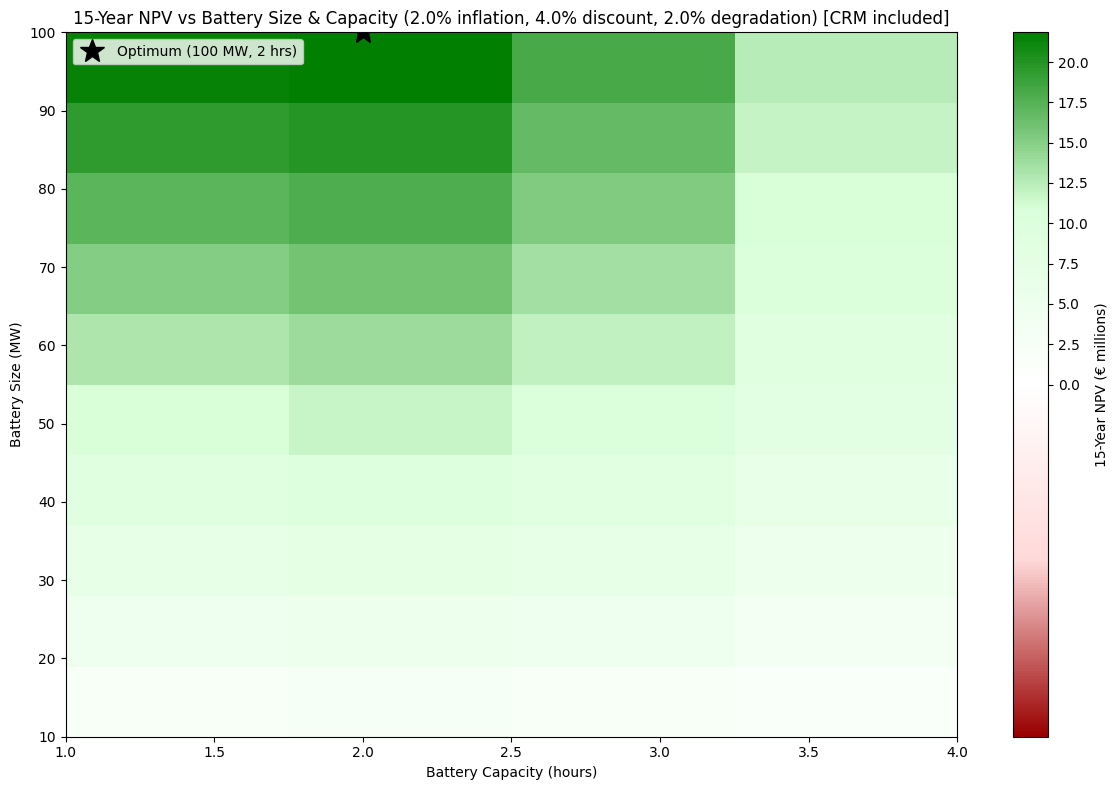

In [123]:
# === Optimise Batt_Size and Batt_Cap to maximise 15-Year NPV ===

import itertools
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

def simulate_npv(Batt_Size_val, Batt_Cap_val):
    """Run the battery simulation and return 15-year NPV (including CRM if enabled)."""
    Batt_Loss_l  = (1 - RTE) / 2
    oml_l        = 1 - Batt_Loss_l
    Max_Charge_l = Batt_Size_val * Batt_Cap_val
    Min_C_l      = Max_Charge_l * min_charge
    Batt_Pow_l   = Batt_Size_val
    init_c_l     = init_charge * Max_Charge_l

    # Pre-compute day-ahead grid charging schedule for this battery size
    if IncludeArbitrage:
        _con_l = df['Constraints'].values.copy()
        if not IncludeConstraints:
            _con_l[:] = 0.0
        _h_l    = df.index.hour.values
        sched_l = compute_grid_charge_schedule(
            Max_Charge_l, Min_C_l, Batt_Pow_l, oml_l,
            _con_l, _h_l, price_arr
        )
    else:
        sched_l = np.zeros(len(df))

    n_l             = len(df)
    node_demand_l   = df['Node Demand (MWh)'].values
    constraints_l   = df['Constraints'].values if IncludeConstraints else np.zeros(n_l)
    prev_charge     = init_c_l
    discharge_rev_l = 0.0
    grid_cost_l     = 0.0
    ds3_revenue_l   = 0.0
    charge_status_l = np.zeros(n_l)
    max_discharge_l = np.zeros(n_l)

    for i in range(n_l):
        nd      = node_demand_l[i]
        dis     = discharging_arr[i]
        con     = constraints_l[i]
        has_con = con > 0

        # Max discharge limited by node demand at this node
        Max_dis = 0.0
        if not has_con and dis and prev_charge > Min_C_l:
            spare   = prev_charge - Min_C_l
            Max_dis = min(spare, Batt_Pow_l, nd / oml_l)
            if Max_dis < 0:
                Max_dis = 0.0
        max_discharge_l[i] = Max_dis

        # Max charge (curtailment-based or time-based via MIC)
        Max_C = 0.0
        if has_con and prev_charge < Max_Charge_l:
            avail = (Max_Charge_l - prev_charge) / oml_l
            Max_C = min(con, Batt_Pow_l, avail)
            if Max_C < 0:
                Max_C = 0.0
        # Additive grid charging from schedule
        gc = sched_l[i]
        if gc > 0 and not has_con and prev_charge < Max_Charge_l:
            avail_space = (Max_Charge_l - prev_charge) / oml_l
            extra       = max(min(gc, avail_space - Max_C), 0.0)
            Max_C      += extra
            grid_cost_l += extra * (price_arr[i] + grid_import_adder)

        # Accumulate discharge revenue and DS3
        discharge_rev_l += Max_dis * oml_l * price_arr[i]

        # Update SOC
        prev_charge        = prev_charge + Max_C * oml_l - Max_dis
        charge_status_l[i] = prev_charge

    # DS3 FFR upward availability revenue
    ds3_headroom_l = np.maximum(0, charge_status_l - Min_C_l)
    ds3_avail_l    = np.minimum(Batt_Pow_l, ds3_headroom_l / Batt_Cap_val) - max_discharge_l
    ds3_avail_l    = np.maximum(0, ds3_avail_l)
    ds3_avail_l    = np.minimum(ds3_avail_l, DS3_MW_CAP)
    ds3_avail_l    = ds3_avail_l * DS3_availability_factor
    ds3_revenue_l  = (ds3_avail_l * ds3_rate_arr).sum()

    # Annual battery operating revenue
    batt_opex_l    = Batt_Cap_val * Batt_Size_val * opex
    net_annual_rev = discharge_rev_l - grid_cost_l + ds3_revenue_l - batt_opex_l

    batt_cost_l = Batt_Cap_val * Batt_Size_val * capex

    # CRM: de-rate by DRF, apply loss factor, inflate over contract term
    crm_drf_l       = get_drf(Batt_Size_val, Batt_Cap_val)
    crm_annual_l    = Batt_Size_val * crm_drf_l * crm_clearing_price * (1 - crm_loss_factor)
    crm_npv_l = sum(
        crm_annual_l * (1 + inflation_rate)**yr / (1 + discount_rate)**yr
        for yr in range(1, crm_contract_term + 1)
    ) if IncludeCRM else 0.0

    ops_npv_l = sum(
        net_annual_rev * (1 - degradation_rate)**yr * (1 + inflation_rate)**yr / (1 + discount_rate)**yr
        for yr in range(1, term + 1)
    )

    _irr_cf_l = [-batt_cost_l]
    for _yr in range(1, term + 1):
        _annual = net_annual_rev * (1 - degradation_rate) ** _yr * (1 + inflation_rate) ** _yr
        if IncludeCRM and _yr <= crm_contract_term:
            _annual += crm_annual_l * (1 + inflation_rate) ** _yr
        _irr_cf_l.append(_annual)
    return -batt_cost_l + crm_npv_l + ops_npv_l, _irr(_irr_cf_l)


# --- Define search ranges ---
size_range = np.arange(10, 110, 10)
cap_range  = [1, 2, 3, 4]

# --- Grid search ---
best_npv  = -np.inf
best_size = None
best_cap  = None
results     = np.full((len(size_range), len(cap_range)), np.nan)
irr_results = np.full((len(size_range), len(cap_range)), np.nan)

for i, sz in enumerate(size_range):
    for j, cp in enumerate(cap_range):
        npv_val, irr_val = simulate_npv(sz, cp)
        results[i, j]     = npv_val
        irr_results[i, j] = irr_val
        if npv_val > best_npv:
            best_npv  = npv_val
            best_size = sz
            best_cap  = cp

print(f"Optimal Batt_Size: {best_size} MW")
print(f"Optimal Batt_Cap:  {best_cap} hrs")
print(f"Maximum 15-year NPV: €{best_npv:,.0f}")
_bi = np.where(size_range == best_size)[0][0]
_bj = cap_range.index(best_cap)
print(f"IRR at optimum:    {irr_results[_bi, _bj]*100:.2f}%" if not np.isnan(irr_results[_bi, _bj]) else "IRR at optimum:    N/A")
print(f"Battery Cost: €{best_size * best_cap * capex:,.0f}")

# --- Custom red-white-green colormap centred at zero ---
red_green_cmap = LinearSegmentedColormap.from_list(
    'RedGreen',
    [(0.6, 0, 0), (1, 0.85, 0.85), (1, 1, 1), (0.85, 1, 0.85), (0, 0.5, 0)],
    N=256
)

results_M = results / 1e6
vmin, vmax = np.nanmin(results_M), np.nanmax(results_M)

if vmin < 0 < vmax:
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
elif vmin >= 0:
    norm = TwoSlopeNorm(vmin=-0.01, vcenter=0, vmax=vmax)
else:
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=0.01)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(results_M, origin='lower', aspect='auto',
               extent=[cap_range[0], cap_range[-1], size_range[0], size_range[-1]],
               cmap=red_green_cmap, norm=norm)
cbar = fig.colorbar(im, ax=ax, label='15-Year NPV (€ millions)')
ax.set_xlabel('Battery Capacity (hours)')
ax.set_ylabel('Battery Size (MW)')
ax.set_title(f'{term}-Year NPV vs Battery Size & Capacity ({inflation_rate*100:.1f}% inflation, '
             f'{discount_rate*100:.1f}% discount, {degradation_rate*100:.1f}% degradation)'
             + (' [CRM included]' if IncludeCRM else ' [CRM excluded]'))
ax.plot(best_cap, best_size, 'k*', markersize=18,
        label=f'Optimum ({best_size} MW, {best_cap} hrs)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [124]:
# === Alpha / Beta Sensitivity Analysis (fixed battery size) ===
# Varies alpha and beta across all available parquet files and computes 15-year NPV
# Battery size/capacity held at current Batt_Size / Batt_Cap values.

from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

def _load_constraints_arr(alpha_val, beta_val):
    """Load and align curtailment_hat_mwh constraints for a given alpha/beta pair."""
    path = (
        f"../../data/processed/curtailment_counterfactual_wind/"
        f"wind_curtailment_node_hour_y{year}_a{float(alpha_val)}_b{float(beta_val)}.parquet"
    )
    c = pd.read_parquet(path)
    c = c[c['node_id'] == node_id][['datetime', 'curtailment_hat_mwh']].copy()
    c = c.set_index('datetime')
    # df.index is UTC-aware; strip tz for alignment
    naive_idx = df.index.tz_convert(None)
    return c['c_mwh'].reindex(naive_idx).fillna(0).values


def simulate_npv_ab(alpha_val, beta_val):
    """Run battery simulation with given alpha/beta constraints; return 15-year NPV including CRM."""
    Batt_Loss_l  = (1 - RTE) / 2
    oml_l        = 1 - Batt_Loss_l
    Max_Charge_l = Batt_Size * Batt_Cap
    Min_C_l      = Max_Charge_l * min_charge
    Batt_Pow_l   = Batt_Size
    init_c_l     = init_charge * Max_Charge_l

    constraints_l = _load_constraints_arr(alpha_val, beta_val)
    if not IncludeConstraints:
        constraints_l = np.zeros_like(constraints_l)

    if IncludeArbitrage:
        sched_l = compute_grid_charge_schedule(
            Max_Charge_l, Min_C_l, Batt_Pow_l, oml_l,
            constraints_l, df.index.hour.values, price_arr
        )
    else:
        sched_l = np.zeros(len(df))

    n_l             = len(df)
    node_demand_l   = df['Node Demand (MWh)'].values
    prev_charge     = init_c_l
    discharge_rev_l = 0.0
    grid_cost_l     = 0.0
    charge_status_l = np.zeros(n_l)
    max_discharge_l = np.zeros(n_l)

    for i in range(n_l):
        nd      = node_demand_l[i]
        dis     = discharging_arr[i]
        con     = constraints_l[i]
        has_con = con > 0

        Max_dis = 0.0
        if not has_con and dis and prev_charge > Min_C_l:
            spare   = prev_charge - Min_C_l
            Max_dis = min(spare, Batt_Pow_l, nd / oml_l)
            if Max_dis < 0:
                Max_dis = 0.0
        max_discharge_l[i] = Max_dis

        Max_C = 0.0
        if has_con and prev_charge < Max_Charge_l:
            avail = (Max_Charge_l - prev_charge) / oml_l
            Max_C = min(con, Batt_Pow_l, avail)
            if Max_C < 0:
                Max_C = 0.0
        gc = sched_l[i]
        if gc > 0 and not has_con and prev_charge < Max_Charge_l:
            avail_space = (Max_Charge_l - prev_charge) / oml_l
            extra       = max(min(gc, avail_space - Max_C), 0.0)
            Max_C      += extra
            grid_cost_l += extra * (price_arr[i] + grid_import_adder)

        discharge_rev_l += Max_dis * oml_l * price_arr[i]
        prev_charge      = prev_charge + Max_C * oml_l - Max_dis
        charge_status_l[i] = prev_charge

    ds3_headroom_l = np.maximum(0, charge_status_l - Min_C_l)
    ds3_avail_l    = np.minimum(Batt_Pow_l, ds3_headroom_l / Batt_Cap) - max_discharge_l
    ds3_avail_l    = np.maximum(0, ds3_avail_l)
    ds3_avail_l    = np.minimum(ds3_avail_l, DS3_MW_CAP)
    ds3_avail_l    = ds3_avail_l * DS3_availability_factor
    ds3_revenue_l  = (ds3_avail_l * ds3_rate_arr).sum()

    batt_opex_l    = Batt_Cap * Batt_Size * opex
    net_annual_rev = discharge_rev_l - grid_cost_l + ds3_revenue_l - batt_opex_l
    batt_cost_l    = Batt_Cap * Batt_Size * capex

    crm_drf_l    = get_drf(Batt_Size, Batt_Cap)
    crm_annual_l = Batt_Size * crm_drf_l * crm_clearing_price * (1 - crm_loss_factor)
    crm_npv_l = sum(
        crm_annual_l * (1 + inflation_rate)**yr / (1 + discount_rate)**yr
        for yr in range(1, crm_contract_term + 1)
    ) if IncludeCRM else 0.0

    ops_npv_l = sum(
        net_annual_rev * (1 - degradation_rate)**yr * (1 + inflation_rate)**yr / (1 + discount_rate)**yr
        for yr in range(1, term + 1)
    )
    return -batt_cost_l + crm_npv_l + ops_npv_l


# --- Define search ranges (must match available parquet files) ---
alpha_range = [1.0, 2.0]
beta_range  = [1.0, 1.5]

# --- Grid search ---
best_npv   = -np.inf
best_alpha = None
best_beta  = None
ab_results = np.full((len(beta_range), len(alpha_range)), np.nan)

for j, b in enumerate(beta_range):
    for i, a in enumerate(alpha_range):
        npv_val = simulate_npv_ab(a, b)
        ab_results[j, i] = npv_val
        if npv_val > best_npv:
            best_npv   = npv_val
            best_alpha = a
            best_beta  = b
        print(f"  alpha={a}, beta={b} → NPV €{npv_val:,.0f}")

print(f"\nOptimal alpha: {best_alpha}")
print(f"Optimal beta:  {best_beta}")
print(f"Maximum {term}-year NPV: €{best_npv:,.0f}")

# --- Heatmap ---
red_green_cmap = LinearSegmentedColormap.from_list(
    'RedGreen',
    [(0.6, 0, 0), (1, 0.85, 0.85), (1, 1, 1), (0.85, 1, 0.85), (0, 0.5, 0)],
    N=256
)

results_M = ab_results / 1e6
vmin, vmax = np.nanmin(results_M), np.nanmax(results_M)
if vmin < 0 < vmax:
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
elif vmin >= 0:
    norm = TwoSlopeNorm(vmin=-0.01, vcenter=0, vmax=vmax)
else:
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=0.01)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(
    results_M, origin='lower', aspect='auto',
    extent=[alpha_range[0], alpha_range[-1], beta_range[0], beta_range[-1]],
    cmap=red_green_cmap, norm=norm
)
fig.colorbar(im, ax=ax, label=f'{term}-Year NPV (€ millions)')
ax.set_xlabel('Alpha')
ax.set_ylabel('Beta')
ax.set_title(
    f'{term}-Year NPV vs Alpha & Beta\n'
    f'{node_id} | {Batt_Size} MW / {Batt_Cap} hr battery'
    + (' [CRM included]' if IncludeCRM else ' [CRM excluded]')
)
ax.plot(best_alpha, best_beta, 'k*', markersize=18,
        label=f'Optimum (α={best_alpha}, β={best_beta})')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '../../data/processed/curtailment_counterfactual_wind/wind_curtailment_node_hour_y2025_a1.0_b1.0.parquet'

  α=1.0, β=1.0  (40/80 runs, 2s elapsed)
  α=2.0, β=1.0  (80/80 runs, 3s elapsed)

Done — 80 simulations in 3.4s

Global optimum:
  alpha=2.0,  beta=1.0
  Batt_Size=100 MW,  Batt_Cap=1 hrs
  15-year NPV: €25,217,718
  IRR:           18.56%


/var/folders/1_/c20kcvnx3hd7mshd18h4nnwm0000gn/T/ipykernel_29519/1628092643.py:158: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im1 = ax1.imshow(M, origin='lower', aspect='auto',


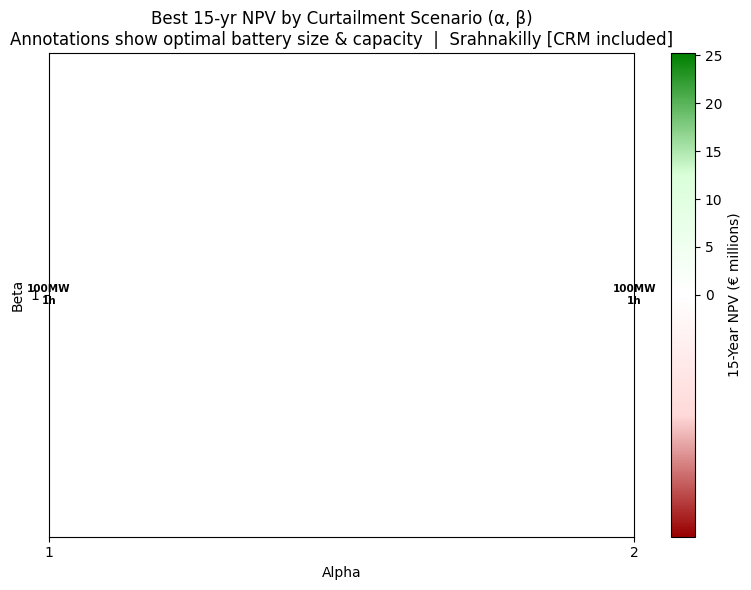

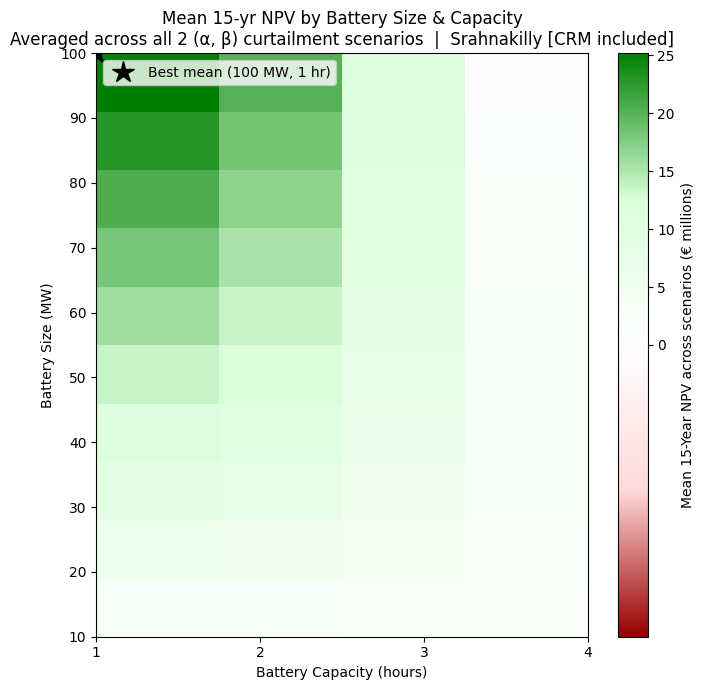

In [ ]:
# === Combined Sensitivity: All Alpha/Beta × All Battery Sizes ===
# For every (alpha, beta) curtailment scenario × (Batt_Size, Batt_Cap) combination,
# compute the 15-year NPV.  Results shape: (n_beta, n_alpha, n_size, n_cap)

import itertools
import time
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.ticker as ticker

alpha_range_full = [1.0, 2.0]
beta_range_full  = [1.0]
size_range_full  = np.arange(10, 110, 10)   # 10 MW steps
cap_range_full   = [1, 2, 3, 4]             # hours


def simulate_npv_full(constraints_l, Batt_Size_val, Batt_Cap_val):
    """
    Run battery simulation for given pre-loaded constraints array and battery spec.
    Returns 15-year NPV including CRM (float).
    """
    Batt_Loss_l  = (1 - RTE) / 2
    oml_l        = 1 - Batt_Loss_l
    Max_Charge_l = Batt_Size_val * Batt_Cap_val
    Min_C_l      = Max_Charge_l * min_charge
    Batt_Pow_l   = Batt_Size_val
    init_c_l     = init_charge * Max_Charge_l

    _con_l = constraints_l if IncludeConstraints else np.zeros_like(constraints_l)

    if IncludeArbitrage:
        sched_l = compute_grid_charge_schedule(
            Max_Charge_l, Min_C_l, Batt_Pow_l, oml_l,
            _con_l, df.index.hour.values, price_arr
        )
    else:
        sched_l = np.zeros(len(df))

    n_l             = len(df)
    node_demand_l   = df['Node Demand (MWh)'].values
    prev_charge     = init_c_l
    discharge_rev_l = 0.0
    grid_cost_l     = 0.0
    charge_status_l = np.zeros(n_l)
    max_discharge_l = np.zeros(n_l)

    for i in range(n_l):
        nd      = node_demand_l[i]
        dis     = discharging_arr[i]
        con     = _con_l[i]
        has_con = con > 0

        Max_dis = 0.0
        if not has_con and dis and prev_charge > Min_C_l:
            spare   = prev_charge - Min_C_l
            Max_dis = min(spare, Batt_Pow_l, nd / oml_l)
            if Max_dis < 0:
                Max_dis = 0.0
        max_discharge_l[i] = Max_dis

        Max_C = 0.0
        if has_con and prev_charge < Max_Charge_l:
            avail = (Max_Charge_l - prev_charge) / oml_l
            Max_C = min(con, Batt_Pow_l, avail)
            if Max_C < 0:
                Max_C = 0.0
        gc = sched_l[i]
        if gc > 0 and not has_con and prev_charge < Max_Charge_l:
            avail_space = (Max_Charge_l - prev_charge) / oml_l
            extra       = max(min(gc, avail_space - Max_C), 0.0)
            Max_C      += extra
            grid_cost_l += extra * (price_arr[i] + grid_import_adder)

        discharge_rev_l    += Max_dis * oml_l * price_arr[i]
        prev_charge         = prev_charge + Max_C * oml_l - Max_dis
        charge_status_l[i]  = prev_charge

    ds3_headroom_l = np.maximum(0, charge_status_l - Min_C_l)
    ds3_avail_l    = np.minimum(Batt_Pow_l, ds3_headroom_l / Batt_Cap_val) - max_discharge_l
    ds3_avail_l    = np.maximum(0, ds3_avail_l)
    ds3_avail_l    = np.minimum(ds3_avail_l, DS3_MW_CAP)
    ds3_avail_l    = ds3_avail_l * DS3_availability_factor
    ds3_revenue_l  = (ds3_avail_l * ds3_rate_arr).sum()

    batt_opex_l    = Batt_Cap_val * Batt_Size_val * opex
    net_annual_rev = discharge_rev_l - grid_cost_l + ds3_revenue_l - batt_opex_l
    batt_cost_l    = Batt_Cap_val * Batt_Size_val * capex

    crm_drf_l    = get_drf(Batt_Size_val, Batt_Cap_val)
    crm_annual_l = Batt_Size_val * crm_drf_l * crm_clearing_price * (1 - crm_loss_factor)
    crm_npv_l = sum(
        crm_annual_l * (1 + inflation_rate)**yr / (1 + discount_rate)**yr
        for yr in range(1, crm_contract_term + 1)
    ) if IncludeCRM else 0.0

    ops_npv_l = sum(
        net_annual_rev * (1 - degradation_rate)**yr * (1 + inflation_rate)**yr / (1 + discount_rate)**yr
        for yr in range(1, term + 1)
    )
    _irr_cf_l = [-batt_cost_l]
    for _yr in range(1, term + 1):
        _annual = net_annual_rev * (1 - degradation_rate) ** _yr * (1 + inflation_rate) ** _yr
        if IncludeCRM and _yr <= crm_contract_term:
            _annual += crm_annual_l * (1 + inflation_rate) ** _yr
        _irr_cf_l.append(_annual)
    return -batt_cost_l + crm_npv_l + ops_npv_l, _irr(_irr_cf_l)


# ── Grid search ────────────────────────────────────────────────────────────────
na, nb, ns, nc = (len(alpha_range_full), len(beta_range_full),
                  len(size_range_full),  len(cap_range_full))

# results[bi, ai, si, ci] = NPV
full_results     = np.full((nb, na, ns, nc), np.nan)
irr_results_full = np.full((nb, na, ns, nc), np.nan)

t0 = time.time()
total_runs = na * nb * ns * nc
done = 0

for bi, b in enumerate(beta_range_full):
    for ai, a in enumerate(alpha_range_full):
        con_arr_ab = _load_constraints_arr(a, b)
        for si, sz in enumerate(size_range_full):
            for ci, cp in enumerate(cap_range_full):
                full_results[bi, ai, si, ci], irr_results_full[bi, ai, si, ci] = simulate_npv_full(con_arr_ab, sz, cp)
                done += 1

        print(f"  α={a}, β={b}  ({done}/{total_runs} runs, {time.time()-t0:.0f}s elapsed)")

print(f"\nDone — {total_runs} simulations in {time.time()-t0:.1f}s")

# ── Global optimum ─────────────────────────────────────────────────────────────
flat_best = np.nanargmax(full_results)
bi_b, ai_b, si_b, ci_b = np.unravel_index(flat_best, full_results.shape)
print(f"\nGlobal optimum:")
print(f"  alpha={alpha_range_full[ai_b]},  beta={beta_range_full[bi_b]}")
print(f"  Batt_Size={size_range_full[si_b]} MW,  Batt_Cap={cap_range_full[ci_b]} hrs")
print(f"  {term}-year NPV: €{full_results[bi_b, ai_b, si_b, ci_b]:,.0f}")
_best_irr_full = irr_results_full[bi_b, ai_b, si_b, ci_b]
print(f"  IRR:           {_best_irr_full*100:.2f}%" if not np.isnan(_best_irr_full) else "  IRR:           N/A")


# ── Plot 1: Best NPV per (alpha, beta) – optimised over battery size/cap ───────
best_npv_per_ab = np.nanmax(full_results, axis=(2, 3))          # shape (nb, na)
best_size_per_ab_flat = np.nanargmax(
    full_results.reshape(nb, na, -1), axis=2)
best_si_ab, best_ci_ab = np.unravel_index(
    best_size_per_ab_flat, (ns, nc))

red_green = LinearSegmentedColormap.from_list(
    'RG', [(0.6,0,0),(1,0.85,0.85),(1,1,1),(0.85,1,0.85),(0,0.5,0)], N=256)

M = best_npv_per_ab / 1e6
vmin, vmax = np.nanmin(M), np.nanmax(M)
norm = TwoSlopeNorm(vmin=min(vmin,-0.01), vcenter=0, vmax=max(vmax,0.01))

fig1, ax1 = plt.subplots(figsize=(8, 6))
im1 = ax1.imshow(M, origin='lower', aspect='auto',
                 extent=[alpha_range_full[0], alpha_range_full[-1],
                         beta_range_full[0],  beta_range_full[-1]],
                 cmap=red_green, norm=norm)
fig1.colorbar(im1, ax=ax1, label=f'{term}-Year NPV (€ millions)')

for bi2, b2 in enumerate(beta_range_full):
    for ai2, a2 in enumerate(alpha_range_full):
        opt_sz = size_range_full[best_si_ab[bi2, ai2]]
        opt_cp = cap_range_full[best_ci_ab[bi2, ai2]]
        ax1.text(a2, b2, f"{opt_sz}MW\n{opt_cp}h",
                 ha='center', va='center', fontsize=7.5,
                 color='black', fontweight='bold')

ax1.set_xticks(alpha_range_full)
ax1.set_yticks(beta_range_full)
ax1.set_xlabel('Alpha')
ax1.set_ylabel('Beta')
ax1.set_title(
    f'Best {term}-yr NPV by Curtailment Scenario (α, β)\n'
    f'Annotations show optimal battery size & capacity  |  {node_id}'
    + (' [CRM included]' if IncludeCRM else ' [CRM excluded]'))
plt.tight_layout()
plt.show()


# ── Plot 2: Mean NPV per (Batt_Size, Batt_Cap) across all (alpha, beta) scenarios
mean_npv_per_batt = np.nanmean(full_results, axis=(0, 1))       # shape (ns, nc)

M2 = mean_npv_per_batt / 1e6
vmin2, vmax2 = np.nanmin(M2), np.nanmax(M2)
norm2 = TwoSlopeNorm(vmin=min(vmin2,-0.01), vcenter=0, vmax=max(vmax2,0.01))

fig2, ax2 = plt.subplots(figsize=(7, 7))
im2 = ax2.imshow(M2, origin='lower', aspect='auto',
                 extent=[cap_range_full[0],  cap_range_full[-1],
                         size_range_full[0], size_range_full[-1]],
                 cmap=red_green, norm=norm2)
fig2.colorbar(im2, ax=ax2, label=f'Mean {term}-Year NPV across scenarios (€ millions)')

mean_best_flat = np.nanargmax(M2)
mean_si, mean_ci = np.unravel_index(mean_best_flat, M2.shape)
ax2.plot(cap_range_full[mean_ci], size_range_full[mean_si],
         'k*', markersize=16,
         label=f'Best mean ({size_range_full[mean_si]} MW, {cap_range_full[mean_ci]} hr)')

ax2.set_xticks(cap_range_full)
ax2.set_yticks(size_range_full)
ax2.set_xlabel('Battery Capacity (hours)')
ax2.set_ylabel('Battery Size (MW)')
ax2.set_title(
    f'Mean {term}-yr NPV by Battery Size & Capacity\n'
    f'Averaged across all {na*nb} (α, β) curtailment scenarios  |  {node_id}'
    + (' [CRM included]' if IncludeCRM else ' [CRM excluded]'))
ax2.legend(loc='upper left')
plt.tight_layout()
plt.show()


Nodes with full wind data: 82
  α=1.0, β=1.0  — 3,280/6,560  (117s elapsed, ~2 min remaining)
  α=2.0, β=1.0  — 6,560/6,560  (241s elapsed, ~0 min remaining)

Complete: 6,560 simulations in 241.1s

Global best node: Srahnakilly
  α=2.0, β=1.0
  100 MW / 1 hr
  15-yr NPV: €25,217,718

Most robust battery (mean NPV across all nodes & scenarios): 90 MW / 1 hr  — mean NPV €7,381,155


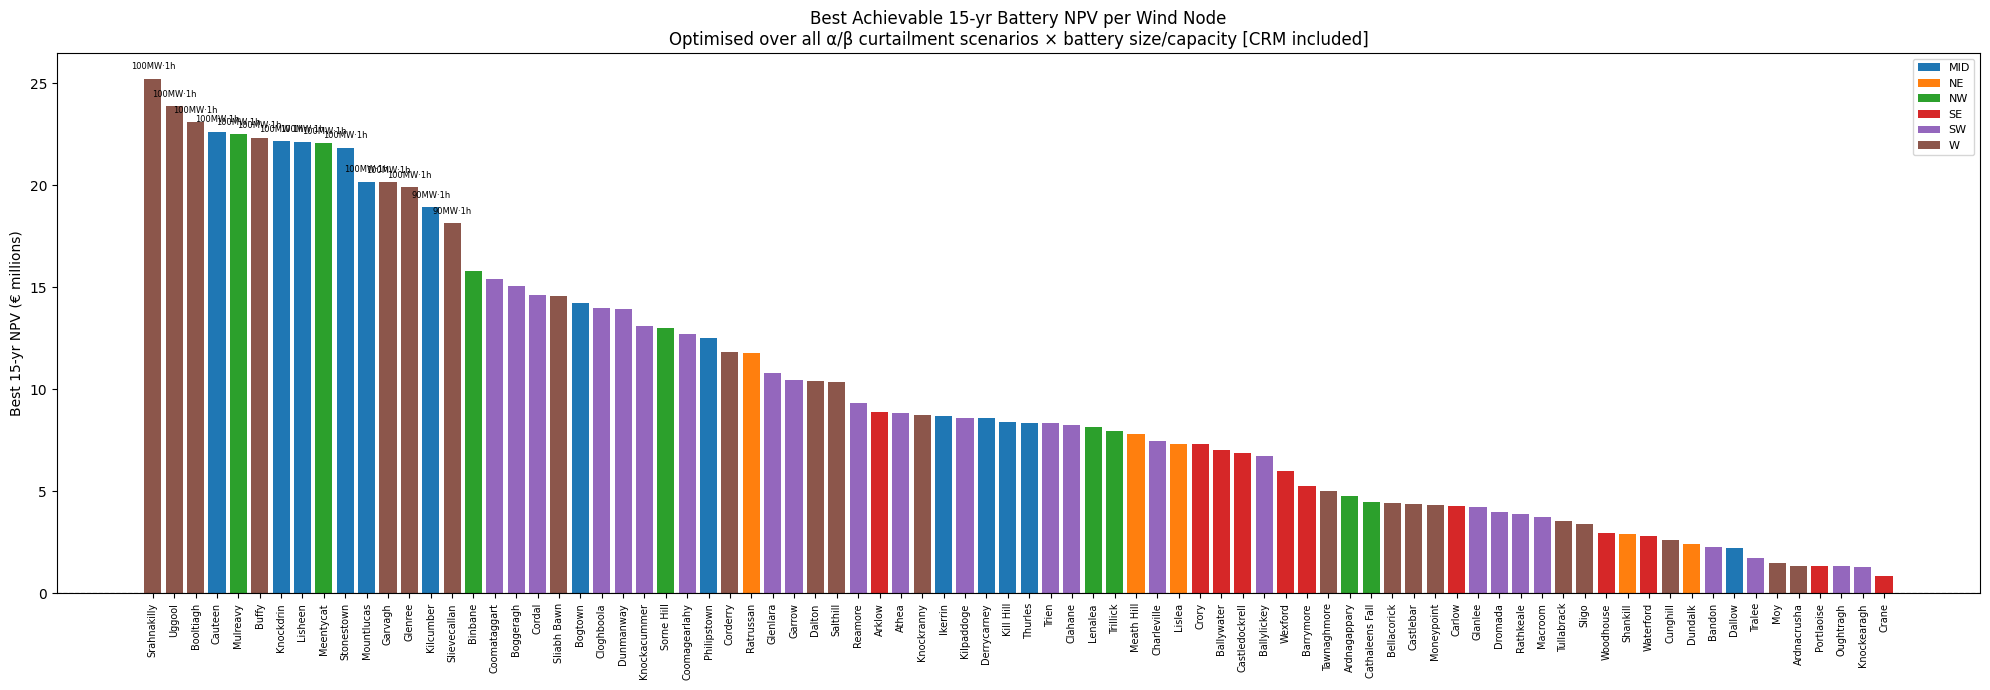

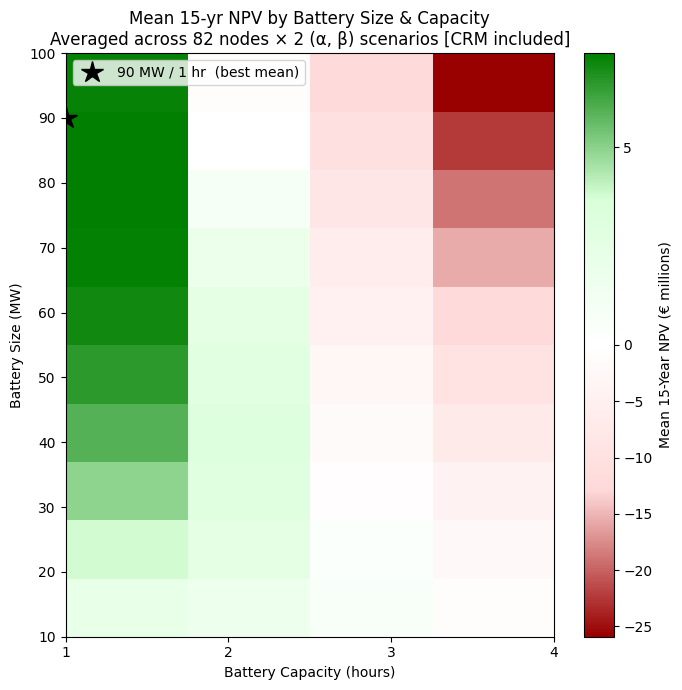

In [ ]:
# === Full Sweep: All Nodes × All Alpha/Beta × All Battery Sizes ===
# Constraints parquet loaded once per (α,β) pair, covering all nodes in one read.

import time
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.patches import Patch

# ── 1. Load all static data once ──────────────────────────────────────────────

nodes_df    = pd.read_csv("../../data/raw/nodes.csv")
node_region = dict(zip(nodes_df['Node'], nodes_df['Region']))

# Availability for every wind node
df_avail_all = pd.read_parquet(
    f"../../data/processed/availability_node_hourly_calibrated/"
    f"availability_nodes_{year}_calibrated.parquet"
)
df_avail_all = df_avail_all[df_avail_all['technology'] == technology]

# Canonical datetime index — tz-naive so it aligns with constraints & demand
_ref_node  = df_avail_all['node_id'].iloc[0]
_ref_avail = df_avail_all[df_avail_all['node_id'] == _ref_node].set_index('datetime').sort_index()
ref_idx    = _ref_avail.index
if ref_idx.tz is not None:
    ref_idx = ref_idx.tz_convert(None)
_hours_all = ref_idx.hour.values

# Availability arrays per node
avail_by_node = {}
for node, grp in df_avail_all.groupby('node_id'):
    s = grp.set_index('datetime').sort_index()['available_mwh']
    if s.index.tz is not None:
        s = s.tz_convert(None)
    avail_by_node[node] = s.reindex(ref_idx).fillna(0).values

# Node demand
nd_all = pd.read_csv("../../data/processed/demand/node_demand_hourly.csv")
nd_all['DateTime'] = pd.to_datetime(nd_all['DateTime'], utc=True).dt.tz_convert(None)
nd_all = nd_all.set_index('DateTime')

# Valid nodes: present in both availability and constraints parquet
_sample_con = pd.read_parquet(
    f"../../data/processed/curtailment_counterfactual_wind/"
    f"wind_curtailment_node_hour_y{year}_a2.0_b1.0.parquet"
)
valid_nodes = sorted(set(avail_by_node) & set(_sample_con['node_id'].unique()))
del _sample_con
print(f"Nodes with full wind data: {len(valid_nodes)}")

# Connection capacity per node from generators.csv — all technologies combined
_gen_df = pd.read_csv("../../data/raw/generators.csv")
_cap_by_node = (
    _gen_df
    .groupby('node_id')['rated_MW'].sum()
    .to_dict()
)

# Price array — same for every node
_price_all = np.array([
    price_lookup.get((ts.month, ts.day, ts.hour), elec_price)
    for ts in ref_idx
])

# DS3 rate array — same for every node (TSS-weighted full stack)
_ds3_rate_all = ds3_rate_arr

# Discharging window
if IncludeArbitrage:
    _ads, _ade = ArbitrageDischargeWindow
    _dchg = ((_hours_all >= _ads) & (_hours_all < _ade)).astype(int)
else:
    _dchg = np.ones(len(ref_idx), int)

# ── 2. Search ranges ──────────────────────────────────────────────────────────

_alpha_r = [1.0, 2.0]
_beta_r  = [1.0]
_size_r  = np.arange(10, 110, 10)
_cap_r   = [1, 2, 3, 4]

_nn, _nb, _na, _ns, _nc = (len(valid_nodes), len(_beta_r), len(_alpha_r),
                            len(_size_r), len(_cap_r))

# node_results[ni, bi, ai, si, ci] = 15-yr NPV
node_results = np.full((_nn, _nb, _na, _ns, _nc), np.nan)
irr_results  = np.full((_nn, _nb, _na, _ns, _nc), np.nan)

# ── 3. Simulation kernel ──────────────────────────────────────────────────────

def _sim(con_l, nd_l, sz, cp, sched_l, node_cap):
    """Battery simulation for one (node, α, β, size, cap). Returns NPV float including CRM."""
    _ol = 1 - (1 - RTE) / 2
    MC  = sz * cp;  mC = MC * min_charge;  ic = init_charge * MC
    prev = ic;  dr = 0.0;  gc_cost = 0.0
    cs = np.zeros(len(nd_l));  md = np.zeros(len(nd_l))

    for i in range(len(nd_l)):
        c = con_l[i];  hc = c > 0
        Dis = 0.0
        if not hc and _dchg[i] and prev > mC:
            Dis = min(prev - mC, sz, nd_l[i] / _ol);  Dis = max(Dis, 0.0)
        md[i] = Dis

        C = 0.0
        if hc and prev < MC:
            C = min(c, sz, (MC - prev) / _ol);  C = max(C, 0.0)
        g = sched_l[i]
        if g > 0 and not hc and prev < MC:
            ex = max(min(g, (MC - prev) / _ol - C), 0.0);  C += ex
            gc_cost += ex * (_price_all[i] + grid_import_adder)

        dr   += Dis * _ol * _price_all[i]
        prev  = prev + C * _ol - Dis
        cs[i] = prev

    ds3h    = np.maximum(0, cs - mC)
    ds3a    = np.minimum(np.maximum(0, np.minimum(sz, ds3h / cp) - md), node_cap) * DS3_availability_factor
    ds3_rev = (ds3a * _ds3_rate_all).sum()

    batt_opex = cp * sz * opex
    net       = dr - gc_cost + ds3_rev - batt_opex
    cost      = cp * sz * capex

    crm_drf    = get_drf(sz, cp)
    crm_annual = sz * crm_drf * crm_clearing_price * (1 - crm_loss_factor)
    crm_npv = sum(
        crm_annual * (1 + inflation_rate)**yr / (1 + discount_rate)**yr
        for yr in range(1, crm_contract_term + 1)
    ) if IncludeCRM else 0.0

    ops_npv = sum(
        net * (1 - degradation_rate)**yr * (1 + inflation_rate)**yr / (1 + discount_rate)**yr
        for yr in range(1, term + 1)
    )
    _irr_cf = [-cost]
    for _yr in range(1, term + 1):
        _annual = net * (1 - degradation_rate) ** _yr * (1 + inflation_rate) ** _yr
        if IncludeCRM and _yr <= crm_contract_term:
            _annual += crm_annual * (1 + inflation_rate) ** _yr
        _irr_cf.append(_annual)
    return -cost + crm_npv + ops_npv, _irr(_irr_cf)

# ── 4. Main grid search ───────────────────────────────────────────────────────

t0    = time.time()
total = _nn * _nb * _na * _ns * _nc
done  = 0

for bi, b in enumerate(_beta_r):
    for ai, a in enumerate(_alpha_r):
        con_df = pd.read_parquet(
            f"../../data/processed/curtailment_counterfactual_wind/"
            f"wind_curtailment_node_hour_y{year}_a{float(a)}_b{float(b)}.parquet"
        )

        con_by_node = {}
        for node in valid_nodes:
            s = (con_df[con_df['node_id'] == node]
                 .set_index('datetime')['curtailment_hat_mwh'])
            if s.index.tz is not None:
                s = s.tz_convert(None)
            con_by_node[node] = s.reindex(ref_idx).fillna(0).values

        for ni, node in enumerate(valid_nodes):
            con_l = con_by_node[node]
            nd_l  = (nd_all[node].reindex(ref_idx).fillna(0).values
                     if node in nd_all.columns else np.zeros(len(ref_idx)))

            for si, sz in enumerate(_size_r):
                for ci, cp in enumerate(_cap_r):
                    MC = sz * cp;  mC = MC * min_charge;  ol = 1 - (1 - RTE) / 2
                    if IncludeArbitrage:
                        sched = compute_grid_charge_schedule(
                            MC, mC, sz, ol, con_l, _hours_all, _price_all
                        )
                    else:
                        sched = np.zeros(len(ref_idx))
                    node_results[ni, bi, ai, si, ci], irr_results[ni, bi, ai, si, ci] = _sim(con_l, nd_l, sz, cp, sched, _cap_by_node.get(node, DS3_MW_CAP))
                    done += 1

        elapsed = time.time() - t0
        rate    = done / elapsed if elapsed > 0 else 1
        eta     = (total - done) / rate
        print(f"  α={a}, β={b}  — {done:,}/{total:,}  "
              f"({elapsed:.0f}s elapsed, ~{eta/60:.0f} min remaining)")

print(f"\nComplete: {total:,} simulations in {time.time()-t0:.1f}s")

# ── 5. Summary stats ──────────────────────────────────────────────────────────

best_npv_node = np.nanmax(node_results, axis=(1, 2, 3, 4))
_flat_best    = np.nanargmax(node_results.reshape(_nn, -1), axis=1)
_best_bi, _best_ai, _best_si, _best_ci = np.unravel_index(_flat_best, (_nb, _na, _ns, _nc))

g_ni = int(np.nanargmax(best_npv_node))
print(f"\nGlobal best node: {valid_nodes[g_ni]}")
print(f"  α={_alpha_r[_best_ai[g_ni]]}, β={_beta_r[_best_bi[g_ni]]}")
print(f"  {_size_r[_best_si[g_ni]]} MW / {_cap_r[_best_ci[g_ni]]} hr")
print(f"  {term}-yr NPV: €{best_npv_node[g_ni]:,.0f}")

mean_batt = np.nanmean(node_results, axis=(0, 1, 2))  # shape (ns, nc)
mean_best_si, mean_best_ci = np.unravel_index(np.nanargmax(mean_batt), mean_batt.shape)
print(f"\nMost robust battery (mean NPV across all nodes & scenarios): "
      f"{_size_r[mean_best_si]} MW / {_cap_r[mean_best_ci]} hr  "
      f"— mean NPV €{mean_batt[mean_best_si, mean_best_ci]:,.0f}")

# ── 6. Plot A: ranked bar chart of best NPV per node ─────────────────────────

region_colors = {'MID':'#1f77b4','NE':'#ff7f0e','NW':'#2ca02c',
                 'SE':'#d62728','SW':'#9467bd','W':'#8c564b'}

order         = np.argsort(best_npv_node)[::-1]
sorted_nodes  = [valid_nodes[i] for i in order]
sorted_npvs   = best_npv_node[order] / 1e6
sorted_colors = [region_colors.get(node_region.get(n, ''), '#aaaaaa') for n in sorted_nodes]
sorted_config = [
    f"{_size_r[_best_si[i]]}MW·{_cap_r[_best_ci[i]]}h"
    for i in order
]

fig_a, ax_a = plt.subplots(figsize=(20, 7))
ax_a.bar(range(len(sorted_nodes)), sorted_npvs, color=sorted_colors, edgecolor='none')
ax_a.axhline(0, color='black', lw=0.8, ls='--')
ax_a.set_xticks(range(len(sorted_nodes)))
ax_a.set_xticklabels(sorted_nodes, rotation=90, fontsize=7)
ax_a.set_ylabel(f'Best {term}-yr NPV (€ millions)')
ax_a.set_title(
    f'Best Achievable {term}-yr Battery NPV per Wind Node\n'
    f'Optimised over all α/β curtailment scenarios × battery size/capacity'
    + (' [CRM included]' if IncludeCRM else ' [CRM excluded]'))
ax_a.legend(
    handles=[Patch(facecolor=c, label=r) for r, c in region_colors.items()],
    loc='upper right', fontsize=8
)
for rank in range(min(15, len(sorted_nodes))):
    ax_a.text(rank, sorted_npvs[rank] + 0.015 * max(sorted_npvs),
              sorted_config[rank], ha='center', va='bottom', fontsize=6)
plt.tight_layout()
plt.show()

# ── 7. Plot B: mean NPV per (size, cap) across all nodes & scenarios ──────────

red_green = LinearSegmentedColormap.from_list(
    'RG', [(0.6,0,0),(1,0.85,0.85),(1,1,1),(0.85,1,0.85),(0,0.5,0)], N=256)

M2    = mean_batt / 1e6
vmin2 = np.nanmin(M2);  vmax2 = np.nanmax(M2)
norm2 = TwoSlopeNorm(vmin=min(vmin2, -0.01), vcenter=0, vmax=max(vmax2, 0.01))

fig_b, ax_b = plt.subplots(figsize=(7, 7))
im_b = ax_b.imshow(M2, origin='lower', aspect='auto',
                   extent=[_cap_r[0], _cap_r[-1], _size_r[0], _size_r[-1]],
                   cmap=red_green, norm=norm2)
fig_b.colorbar(im_b, ax=ax_b, label=f'Mean {term}-Year NPV (€ millions)')
ax_b.plot(_cap_r[mean_best_ci], _size_r[mean_best_si], 'k*', markersize=16,
          label=f'{_size_r[mean_best_si]} MW / {_cap_r[mean_best_ci]} hr  (best mean)')
ax_b.set_xticks(_cap_r);  ax_b.set_yticks(_size_r)
ax_b.set_xlabel('Battery Capacity (hours)')
ax_b.set_ylabel('Battery Size (MW)')
ax_b.set_title(
    f'Mean {term}-yr NPV by Battery Size & Capacity\n'
    f'Averaged across {_nn} nodes × {_na * _nb} (α, β) scenarios'
    + (' [CRM included]' if IncludeCRM else ' [CRM excluded]'))
ax_b.legend(loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
# === Diagnostic: Why does the battery only discharge in some hours? ===

# Condition flags for each hour
unconstrained       = constraints_arr == 0
in_discharge_window = discharging_arr.astype(bool)
has_node_demand     = node_demand_arr > 0
actually_discharged = max_discharge_amt > 0

# Funnel analysis
n_total = len(df)
n_unconstrained     = unconstrained.sum()
n_in_window         = (unconstrained & in_discharge_window).sum()
n_has_demand        = (unconstrained & in_discharge_window & has_node_demand).sum()
n_actual            = actually_discharged.sum()
reason_no_demand    = (unconstrained & in_discharge_window & ~has_node_demand)

print("=== Discharge Funnel (hours/year) ===")
print(f"  Total hours:                           {n_total:>5}")
print(f"  Unconstrained (constraint == 0):       {n_unconstrained:>5}")
print(f"  + In discharge window (17:00-21:00):   {n_in_window:>5}  ← arbitrage restricts to 4 hrs/day")
print(f"  In window but no node demand:          {reason_no_demand.sum():>5}")
print(f"  + Node demand > 0:                     {n_has_demand:>5}")
print(f"  Actually discharged (global):          {n_actual:>5}")
print()

discharge_in_window_with_demand    = (unconstrained & in_discharge_window & has_node_demand & actually_discharged).sum()
discharge_in_window_no_demand      = (unconstrained & in_discharge_window & ~has_node_demand & actually_discharged).sum()
discharge_in_window_constrained    = (in_discharge_window & ~unconstrained & actually_discharged).sum()
discharge_outside_window           = (~in_discharge_window & actually_discharged).sum()

print("=== Discharge Breakdown ===")
print(f"  In window, with demand, discharged:    {discharge_in_window_with_demand:>5}")
print(f"  In window, no demand, discharged:      {discharge_in_window_no_demand:>5}")
print(f"  In window, constrained, discharged:    {discharge_in_window_constrained:>5}")
print(f"  Outside window, discharged:            {discharge_outside_window:>5}")


=== Discharge Funnel (hours/year) ===
  Total hours:                            8760
  Unconstrained (constraint == 0):        3913
  + In discharge window (17:00-21:00):     624  ← arbitrage restricts to 4 hrs/day
  In window but no node demand:              0
  + Node demand > 0:                       624
  Actually discharged (global):            322

=== Discharge Breakdown ===
  In window, with demand, discharged:      322
  In window, no demand, discharged:          0
  In window, constrained, discharged:        0
  Outside window, discharged:                0


In [ ]:
# === Deep Dive: What blocks discharge in "should discharge but didn't" hours? ===

# Reconstruct pre-discharge SOC for each hour
pre_discharge_soc    = np.zeros(len(df))
pre_discharge_soc[0] = init_charge_MWh
for i in range(1, len(df)):
    pre_discharge_soc[i] = charge_status[i - 1]

# Identify the blocked hours
unconstrained       = constraints_arr == 0
in_discharge_window = discharging_arr.astype(bool)
has_node_demand     = node_demand_arr > 0
actually_discharged = max_discharge_amt > 0

could_discharge    = unconstrained & in_discharge_window & has_node_demand
does_not_discharge = could_discharge & ~actually_discharged

n_blocked = does_not_discharge.sum()
print(f"=== Examining {n_blocked} hours where discharge is blocked ===\n")

soc_below_min_at_start  = pre_discharge_soc <= Min_Charge_MWh
blocked_due_to_low_soc  = does_not_discharge & soc_below_min_at_start
other_reasons           = does_not_discharge & ~soc_below_min_at_start

print(f"Low SOC (≤ {Min_Charge_MWh:.2f} MWh) at hour start:  {blocked_due_to_low_soc.sum():>5}")
print(f"Other reasons:                                        {other_reasons.sum():>5}")
print()

if other_reasons.sum() > 0:
    print("WARNING: Found blocked discharge NOT due to low SOC")
    idx_other = np.where(other_reasons)[0][:5]
    for idx in idx_other:
        print(f"  Hour {idx} ({df.index[idx]})")
        print(f"    Pre-discharge SOC: {pre_discharge_soc[idx]:.3f} MWh (min: {Min_Charge_MWh:.3f})")
        print(f"    Node demand:       {node_demand_arr[idx]:.3f} MWh")
        print(f"    Discharging flag:  {discharging_arr[idx]}")
        print(f"    Constraint:        {constraints_arr[idx]:.3f}")

=== Examining 302 hours where discharge is blocked ===

Low SOC (≤ 30.00 MWh) at hour start:    302
Other reasons:                                            0



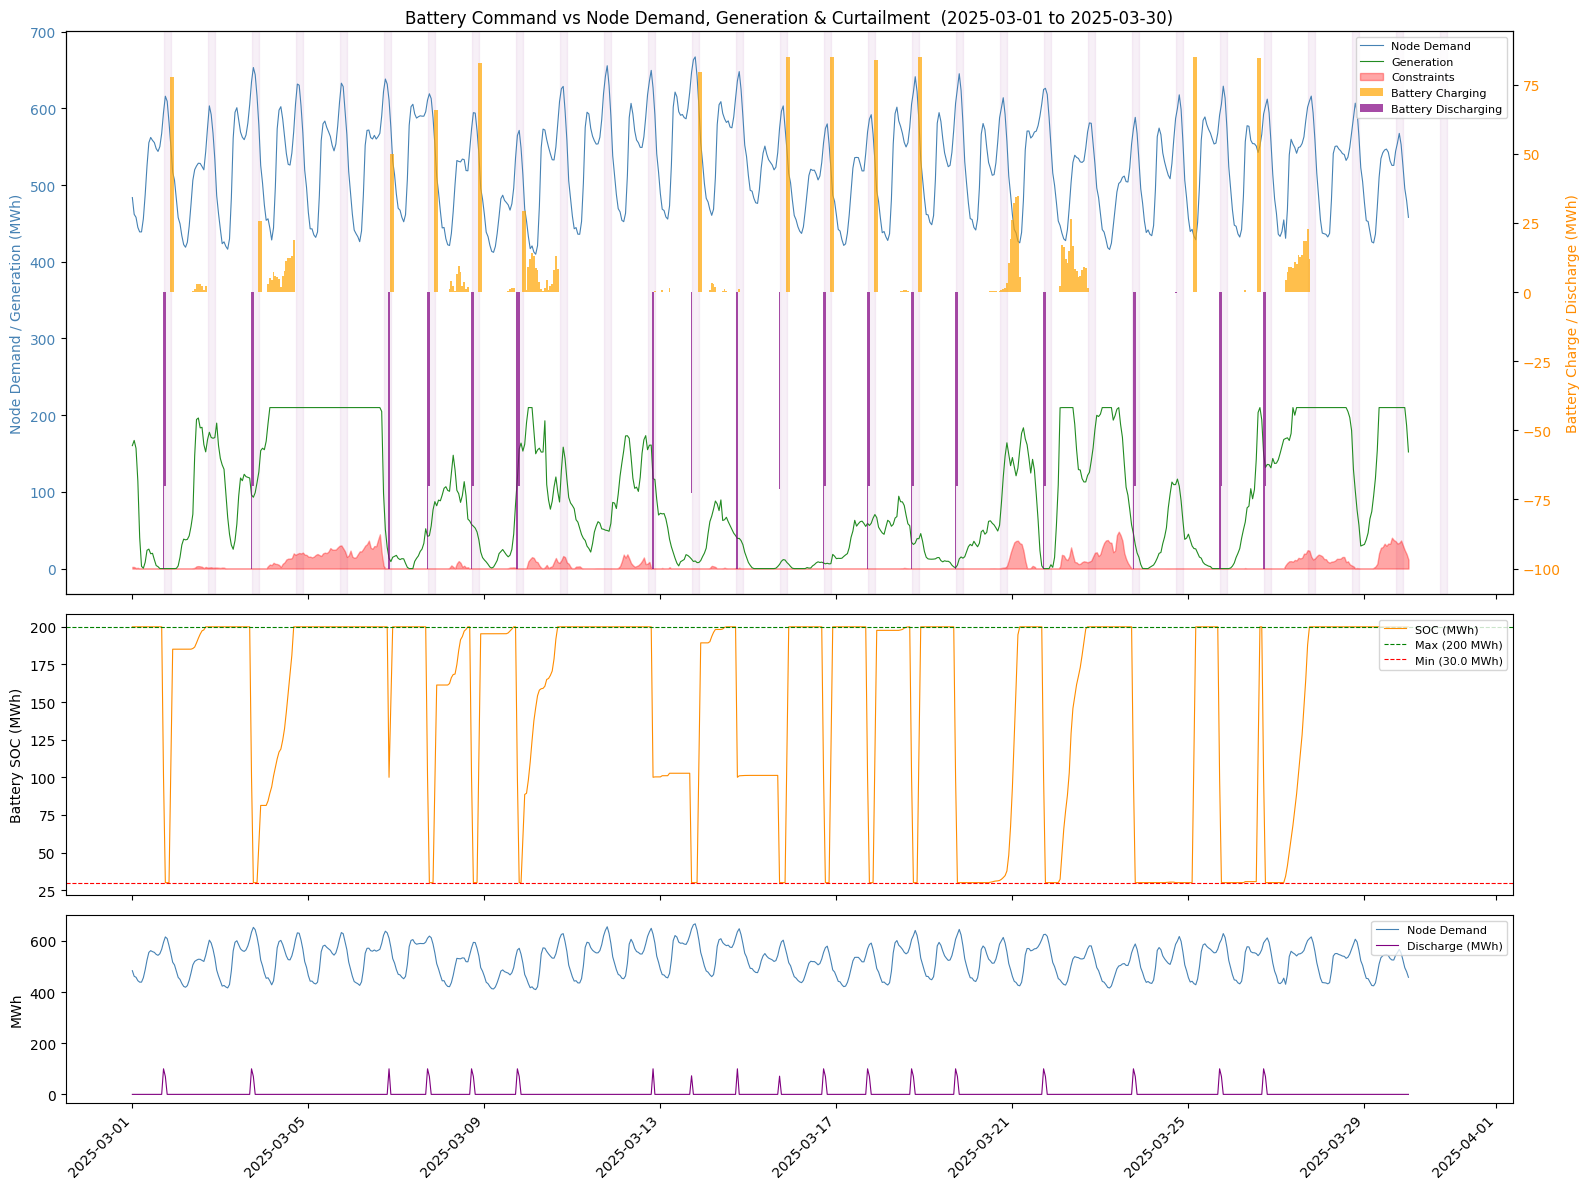

In [ ]:
# === Plot: Battery command vs Node Demand, Generation, and Curtailment ===
# Shows a 1-month window — change plot_start/plot_end to explore

soc_above_min = pre_discharge_soc > Min_Charge_MWh

plot_start = '2025-03-01'
plot_end   = '2025-03-30'

mask = (df.index >= plot_start) & (df.index <= plot_end)
p = df.loc[mask]

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1.5, 1]})

# --- Panel 1: Node Demand, Generation, Constraints on LEFT axis; Battery on RIGHT axis ---
ax1 = axes[0]
ax1.plot(p.index, p['Node Demand (MWh)'], linewidth=0.8, color='steelblue', label='Node Demand')
ax1.plot(p.index, p['Generation (MWh)'],  linewidth=0.8, color='forestgreen', label='Generation')
ax1.fill_between(p.index, 0, p['Constraints'], alpha=0.35, color='red', label='Constraints')
ax1.set_ylabel('Node Demand / Generation (MWh)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Right y-axis for battery charge/discharge
ax1r = ax1.twinx()
charge_vals    = np.where(p['Net Charge'] > 0, p['Net Charge'], 0)
discharge_vals = np.where(p['Net Charge'] < 0, p['Net Charge'], 0)
ax1r.bar(p.index, charge_vals,    width=1/24, color='orange', alpha=0.7, label='Battery Charging')
ax1r.bar(p.index, discharge_vals, width=1/24, color='purple', alpha=0.7, label='Battery Discharging')
ax1r.set_ylabel('Battery Charge / Discharge (MWh)', color='darkorange')
ax1r.tick_params(axis='y', labelcolor='darkorange')

# Shade the discharge window (17:00-21:00) lightly
for day in pd.date_range(plot_start, plot_end, freq='D'):
    ax1.axvspan(day + pd.Timedelta(hours=17), day + pd.Timedelta(hours=21),
                alpha=0.06, color='purple', zorder=0)

ax1.set_title(f'Battery Command vs Node Demand, Generation & Curtailment  ({plot_start} to {plot_end})')

# Combined legend from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1r.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

# --- Panel 2: Battery SOC ---
ax2 = axes[1]
ax2.plot(p.index, p['Charge Status'], color='darkorange', linewidth=0.8, label='SOC (MWh)')
ax2.axhline(Max_Charge,    color='green', linestyle='--', linewidth=0.8, label=f'Max ({Max_Charge} MWh)')
ax2.axhline(Min_Charge_MWh, color='red', linestyle='--', linewidth=0.8, label=f'Min ({Min_Charge_MWh:.1f} MWh)')
ax2.set_ylabel('Battery SOC (MWh)')
ax2.legend(loc='upper right', fontsize=8)

# --- Panel 3: Node Demand vs Discharge ---
ax3 = axes[2]
ax3.plot(p.index, p['Node Demand (MWh)'],  linewidth=0.8, color='steelblue', label='Node Demand')
ax3.plot(p.index, -p['Net Charge'].clip(upper=0), linewidth=0.8, color='purple', label='Discharge (MWh)')
ax3.set_ylabel('MWh')
ax3.legend(loc='upper right', fontsize=8)

fig.autofmt_xdate(rotation=45, ha='right')
plt.tight_layout()
plt.show()